# Lesson 177 · Compute budget realism

Implement three live accounting contracts and reconstruct the complete approved ledger. Standard Python only; no package installation, network access, GPU or paid job. The saved evidence does not become fresh training when replayed. Learner status remains PENDING_WRITTEN_DEFENSE.

In [1]:
from pathlib import Path
import json, math
print("Saved accounting replay; cloud/API spend $0")

Saved accounting replay; cloud/API spend $0


**Your win:** write a feasibility ledger that can reject an unaffordable experiment before it starts—and explain exactly what an affordable run would establish. Allow 15 minutes for the lesson, then use the rest of your session for the notebook.

In [lesson 176](https://avistian.github.io/relational/lessons/0176-few-shot-icl-evaluation.html), you measured what more labeled context buys. The missing question is whether you can afford the **whole protocol**: every model, seed and context, plus preparation, verification and failed attempts. That question connects your [mission](https://avistian.github.io/relational/MISSION.md) to a feasible Year 6 research project.

**Prerequisites:** distinguish pretraining from adaptation ([173](https://avistian.github.io/relational/lessons/0173-multi-task-pretraining.html), [174](https://avistian.github.io/relational/lessons/0174-fine-tuning-protocol.html)); recall why the cheap RT audit stopped in [175](https://avistian.github.io/relational/lessons/0175-zero-shot-evaluation.html). You only need multiplication, units and the idea of a timer inside another timer.

## 1 · What work are you buying?

Pretraining changes shared weights across many tasks. Fine-tuning changes parameters for a selected target setting. In-context prediction uses labeled support with fixed pretrained weights, but still pays for relational features, preprocessing, loading and prediction. [RDBLearn §3](https://arxiv.org/html/2602.18495v1#S3) illustrates the featurization-plus-ICL route; the L176 TabICL comparator is a different pipeline and does not reproduce RDBLearn.

<figure tabindex="0">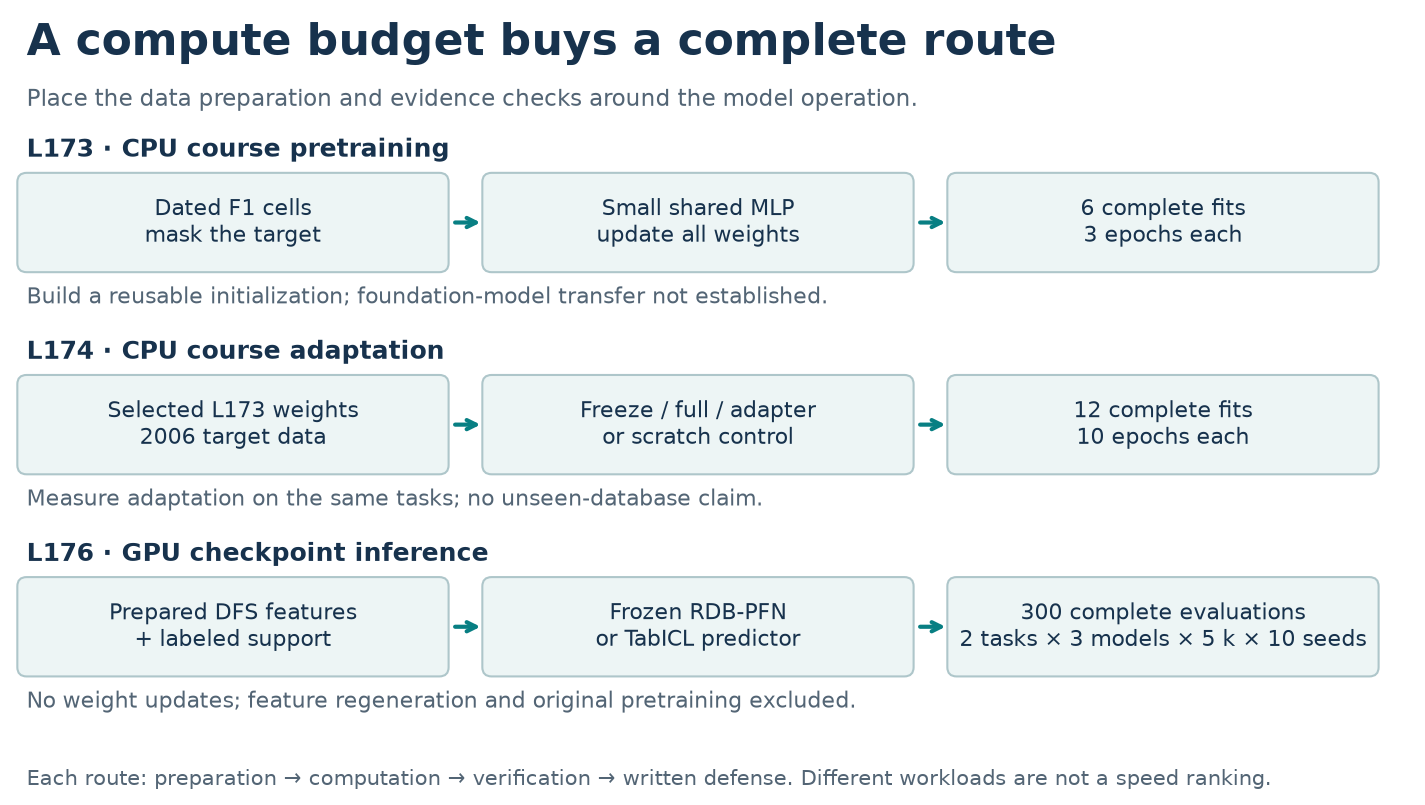<figcaption>Three actual course routes: small-model pretraining, temporal adaptation, and checkpoint inference. Different scopes prevent a speed ranking. Scroll horizontally on narrow screens.</figcaption></figure>

A released checkpoint lets you reuse someone else's pretraining investment. It does not make that investment zero. Likewise, our small CPU pretraining exercise is affordable because of its explicit model and data scope; it does not establish the cost of pretraining a foundation model. **“Pretraining ≫ fine-tuning ≫ ICL” is a planning intuition, not a universal measured ordering.** Compare complete protocols on the same task before claiming an efficiency advantage.

## 2 · Put boundaries around every number

| Evidence | Work completed | Recorded time | What it supports |
|---|---|---|---|
| L173 · local CPU | Six small-model pretraining fits | 51.837 s group; 188.416 s all local commands | Course masked-cell objective; no per-fit timer |
| L174 · local CPU | Twelve adaptation/control fits | 19.566 s sum of fits; 107.588 s all local commands | Four adaptation policies on the course tasks |
| L176 · L4 GPU | All 300 checkpoint evaluations | 491.471 s worker bodies | Two tasks, three models, five context sizes, ten seeds |
| L175 · cloud CPU | Three reserved audit attempts; stopped before GPU inference | 7.641 s in two receipts; first attempt missing | Failed/stopped work still consumes reservations |


These are different workloads and machines. The table describes achieved capabilities; its seconds are **not a speed leaderboard**. L173 lacks individual fit timers. L174 times each fit including evaluation and serialization. The local-command totals also include preparation, audits, failures and notebook validation; their enclosing timers must not be added again to the fit totals. See the [complete ledger](https://avistian.github.io/relational/labs/evidence/l177/report.json) and [timer source](https://avistian.github.io/relational/labs/_run_l176.py).

Predict before continuing: should you add an enclosing worker timer to its internal evaluation timers?

For L176, the worker body took **491.471 seconds** on one L4. Within it, the 300 evaluation timers total **474.434 seconds**. The model-load field is repeated in each receipt: adding all copies gives **23.896 seconds**, but there were only **12 distinct task/model/phase loads**, totaling **0.939 seconds**. The remaining **16.098 seconds** is residual worker work. It is not measured cloud startup time.

<figure tabindex="0">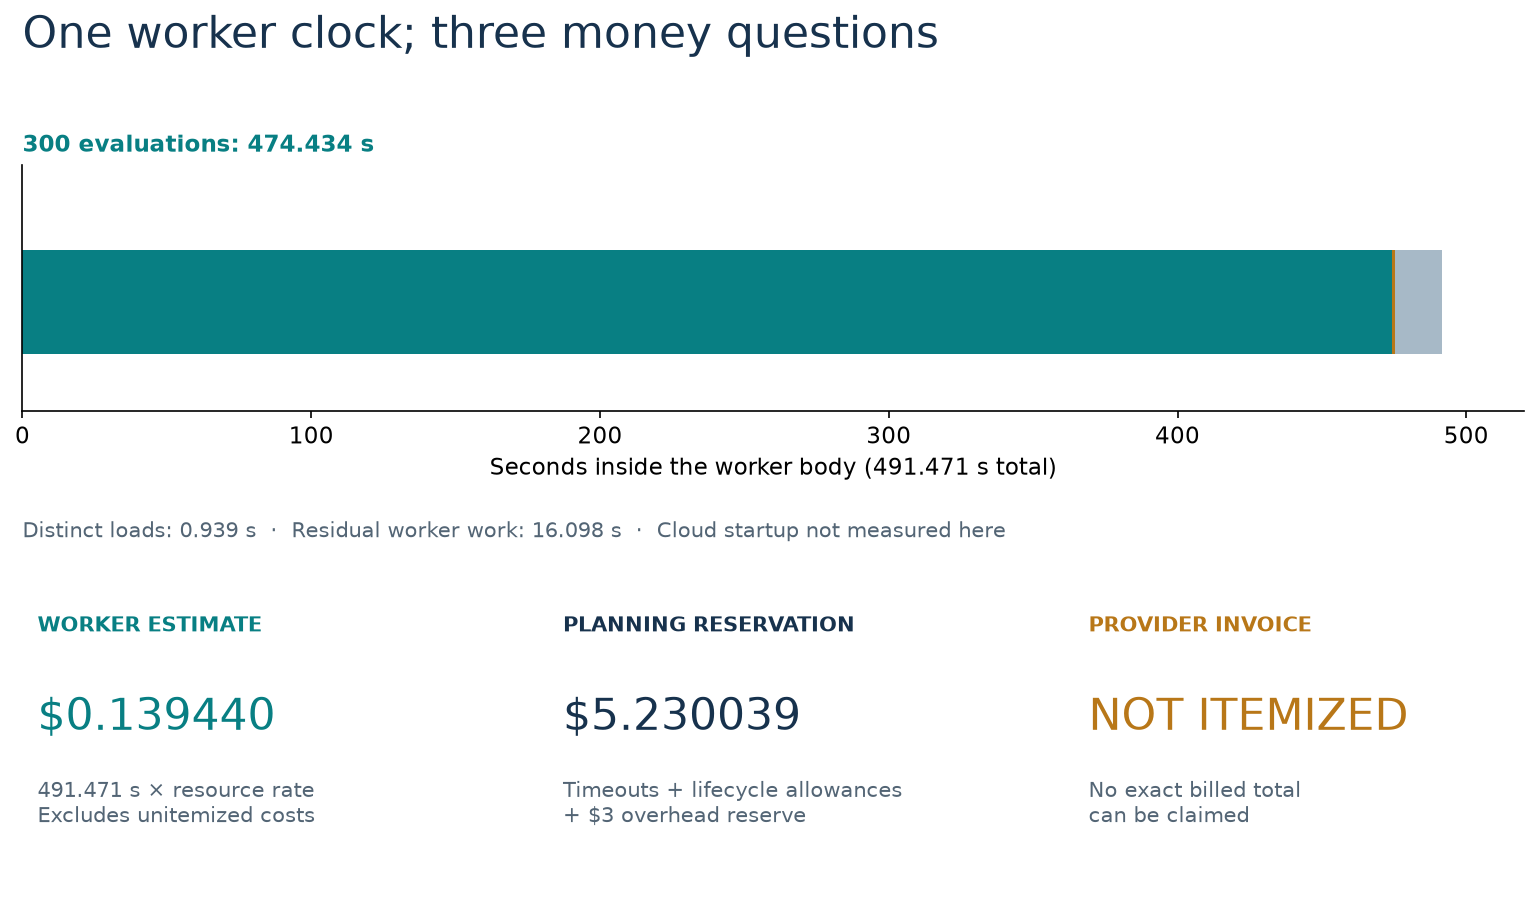<figcaption>The enclosing worker clock contains the inner timers. Estimated worker cost, planning reservation and an unavailable invoice answer different questions. Scroll horizontally on narrow screens.</figcaption></figure>

The **2026-10-02 pricing snapshot** gives this resource-rate calculation:

```text
L4 + 2 physical CPU cores + 16 GiB host RAM
= 0.000222 + 2 × 0.0000131 + 16 × 0.00000222
= $0.00028372 per second

Worker estimate = 491.470908 × rate = $0.139440
Reservation = $3 overhead + (600 + 30 + 7,200 + 30) × rate
            = $5.230039
```

The reservation holds money for timeouts and overhead, including unsuccessful attempts. Do not add the worker estimate to it: that estimate describes work already covered by the reservation. An invoice is a third quantity. L176's remains **NOT_ITEMIZED**. [Modal pricing](https://modal.com/pricing) also bills loading and idle container time, and meters CPU/RAM at the greater of requested or used resources. These are historical planning reservations, not provider-enforced invoice ceilings.

**Memory is another boundary.** The largest L176 PyTorch allocation was **12.052 GiB**. That is allocated tensor memory on the device, not total GPU usage or 16 GiB host RAM. Cached allocations, libraries and other device use can differ. A successful run on the configured L4 is evidence about that run; it does not prove an arbitrary 12 GiB device will fit. See [the pinned PyTorch implementation](https://github.com/pytorch/pytorch/blob/v2.5.1/torch/cuda/memory.py).

<figure tabindex="0">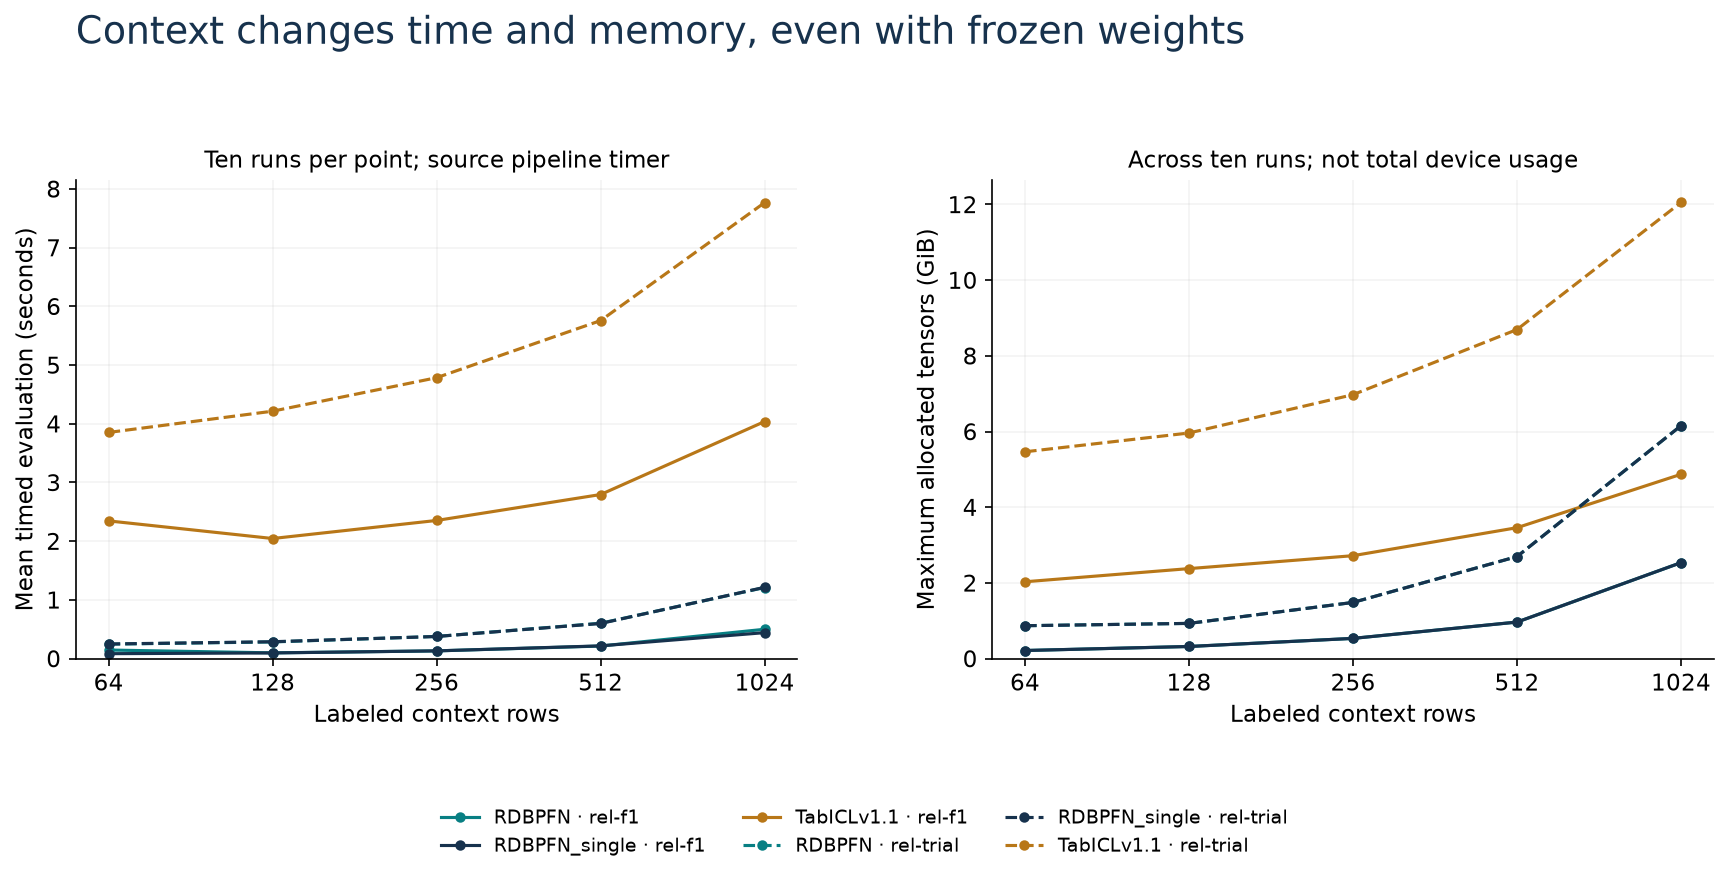<figcaption>Full L176 timing evidence. Solid lines: F1; dashed lines: trial. Time is the ten-seed mean. Memory is the maximum allocated tensor memory across ten runs, not total device usage. Scroll horizontally on narrow screens.</figcaption></figure>

## 3 · Forecast before you know the result

The historical L176 pilot used six runs at k=1,024. Its slowest evaluation took **8.020519 seconds**. Before dispatching the other 294 runs, the declared heuristic was:

```text
294 × slowest pilot × 3 + pilot worker duration
= 294 × 8.020519 × 3 + 27.568350
= 7,101.666 seconds ≈ 118.4 minutes
```

This fit the 7,200-second main timeout and the $8 planned spending stop, leaving $2 of the $10 cap protected. The threefold margin is a heuristic, not a confidence interval. The pilot cannot guarantee runtime at unseen context sizes, on another GPU or with new feature construction. Retain the original forecast even when execution turns out much faster.

Implement the conservative forecast in the live TODO below.

**Parallelism changes two clocks.** Four one-hour jobs on four GPUs can take roughly one elapsed hour while consuming four GPU-hours. They may also require more memory and startup costs. GPU-hours = the sum of GPU count × each job's elapsed hours. Do not use elapsed time alone as a price estimate, or assume that multi-GPU runtime scales linearly onto one GPU.

## 4 · One hour or an extended session?

Human preparation time was not recorded for these experiments. A machine finishing in eight minutes does not establish that a researcher can reproduce the project in eight minutes. Treat one hour as 3,600 seconds and an illustrative extended session as three hours; separate observed evidence from assumptions about your own time.

Use your assess_plan function below to compare baseline and extended scenarios. Missing measurements cannot produce an unconditional admission.

**Try this:** select the L176 forecast, three hours, 20 minutes of active work, and a **hypothetical 16 GiB requirement** on a 24 GiB GPU. The serial scenario fits at about 140.4 minutes, including an assumed two minutes of additional startup. Switch to one hour: it fails the session gate. Restore unknown memory or active work: it cannot earn a complete admission. The calculator does not dispatch a job.

For a baseline session, work through the complete saved ledger, implement one contract, and write your decision. With more time, complete the notebook and investigate a missing measurement. A fresh run still needs its own complete protocol and reservations. L178 will need a matched-task comparison, including feature construction, tuning, evaluation and retries for each paradigm.

## 5 · Some plans must stop

[RT v1 §4.1](https://arxiv.org/html/2510.06377v1#S4.SS1) reports approximately two hours of pretraining or 1.5 hours of fine-tuning on eight A100s per run. That is **16 or 12 GPU-hours**. At the 2026-10-02 A100 40 GB base rate, a hypothetical rental costs **$33.58 or $25.19 for GPUs alone**; the 80 GB scenario is $39.97 or $29.98. These are source-based price scenarios, not measured bills or a promise that either variant reproduces the runtime. Even the cheaper scenario exceeds our $10 cap before CPU, memory, preparation, seeds or retries. Full runs remain **NOT_RUN**.

Money is not the only stop condition. L175 reserved **$3.172199** across its three CPU audit attempts plus overhead/build allowances; one attempt has no worker-time receipt. Its temporal gate failed, so GPU inference remained **NOT_RUN**. A larger budget or longer session cannot repair that scientific failure.

**Run the admission decision by hand.** Consider an invented $5 reservation, 40 minutes of machine work and 10 minutes of active preparation, scheduled serially in a one-hour session. Suppose the plan declares 12 GiB required on a 24 GiB device and uses an $8 spending stop:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Change from plan</th><th>Decision</th><th>Reason</th></tr></thead><tbody><tr><td>None</td><td>Feasible scenario</td><td>50 minutes; declared limits fit</td></tr><tr><td>Required memory unknown</td><td>Incomplete measurement</td><td>Affordability cannot fill the gap</td></tr><tr><td>Preparation takes 25 minutes</td><td>Exceeds session</td><td>40 + 25 = 65 minutes</td></tr><tr><td>Temporal audit fails</td><td>Scientific stop</td><td>Runtime and money are irrelevant to this failure</td></tr></tbody></table>

These are assumed planning inputs, not measured future guarantees. **Transfer check:** give the failed-audit plan three hours and a $100 limit. Its status remains SCIENTIFIC_STOP. Resolve the scientific contract before spending the larger allowance.

## Lab · Rebuild the complete feasibility ledger

[Student notebook](https://avistian.github.io/relational/labs/0177-compute-budget-realism.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0177-compute-budget-realism.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l177-reproduction.md) · [Quick reference](https://avistian.github.io/relational/reference/compute-budget-realism.html)

Implement three live functions: retain every unique attempt reservation; forecast a complete remaining grid; and admit a scenario only when its independent gates pass. They drive the full audit of **300 inference receipts, 18 fit records, and three cloud attempt reservations**. The self-contained packet contains the original accounting records and timer source. No cloud account or checkpoint download is needed.

**Exit:** defend a one-hour and a three-hour plan. Include scope, units, preparation, all seeds/retries, memory evidence, explicit human-time assumptions, protected margin and a scientific stop. Explain why $0.139440, $5.230039 and the missing invoice answer different questions. Revisit your decision after your next timed practice session.

Write your own decision and ask the teacher for feedback.

**Executed:** complete selected accounting replay: **300 inference receipts, 18 fit records, three cloud attempt reservations**. No new model run or cloud/API spend. Fresh training, fresh inference and whole-paper reproduction are `NOT_RUN`; learner status is `PENDING_WRITTEN_DEFENSE`. Invoice reconciliation and live Colab are `NOT_CHECKED`.

**Read next:** [Modal's resource pricing and billing FAQ](https://modal.com/pricing), then trace the timers in the supplied notebook. Ask the teacher about any unclear unit, boundary or budget decision; bring your written ledger for feedback.

**Next lesson:** [178 · Fair model comparison](https://avistian.github.io/relational/lessons/0178-fair-model-comparison.html) asks whether equally budgeted methods actually receive comparable tasks and information.


## PROVIDED · Authenticate the complete original accounting packet
All 300 L176 per-run JSON receipts and phase receipts, all 18 L173/L174 fit records, local attempt ledgers, L175 failure records, timer implementations and pinned primary sources are included. Prediction arrays/checkpoints are outside this accounting audit. Hashes authenticate bytes, not the original truth of a clock or an invoice.

In [2]:
import base64,hashlib,io,zipfile
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='a24bc811988f2e441c50493623ce0fc2d12687e9cf4a12592e9e85bd28f6bf83'
P=Path('l177-packet');P.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(P)
pins={'experiment': 'L177 Compute Feasibility Ledger', 'files': {'_budget_l173.py': 'a6a6da9f6795d9c5ed624c580cae52291237911b83d218afe0c74539e668cd0d', '_budget_l174.py': 'f300d6e94b1d144f572e4d3833b43ef4369ce1564261b77c0235dfead0382a9c', '_budget_l175.py': 'e1cf07e9d525e74738aee9683b5835316c96db00106341814eb78b0f277f3580', '_budget_l176.py': '6a4b71b4e536e69d2a182d6372958b12f702c158b3440e6c224a4673d815e160', '_dispatch_l175.py': 'd21e8bf46ed915ea795c884eeb7d93e466d97e9241e6d01a4191e1daab313b4a', '_run_l173.py': 'e1cf156c83e852d48e9b53f0ea52de10e9435afd2499dcf3091224ea95ccbac5', '_run_l174.py': '02c301a5b2d3b08bea5fcbfbaef9734b21c200e9a1e69a31c8aad44372b396e5', '_run_l176.py': '9d955c74fcf940cbb9ec04a5e2802ef2993ac38b66d3df49dc3a6b394489c33c', 'evidence/l173/cell-0/result.json': '5f4329e7b38202448a566c43140057363ebbf5e3a2161bc6b0d1045f43d4c4c9', 'evidence/l173/cell-1/result.json': '6977590998b67a4fc4c8caee9dbf6c777430b71d8096a3732dc2a25e4539ea37', 'evidence/l173/cell-2/result.json': 'a2c98f75b84c0f9ff953546973d764ff7c1e694246e12e802e47850abd8fb80d', 'evidence/l173/local-budget.json': '7d37f8fbc2bf896c433fec172ed4d0e94e477e2987b6155ec05207bb1138042d', 'evidence/l173/report.json': '20667929cb5102a4d0bc55d2c78c87c896b36b27ea8dbae7a16990d17cfd6474', 'evidence/l173/task-0/result.json': '0f35f7deb098b3b6e3e1a95362c27697de4f820aecbb239eba87aedc776d93de', 'evidence/l173/task-1/result.json': '120dac63f7cbff585dccd5f37bc4937ef9804e1fc08c6fa9ae47c9ba39e4645e', 'evidence/l173/task-2/result.json': 'aa6c136c6ef8822902b84a3b3ba1deeb44b3ec9f78cabfd688b381378a72657c', 'evidence/l174/local-budget.json': '60dd993690d9651ab244db8377d237109639eca668299dc95564ca203b77c7ca', 'evidence/l174/runs/adapter-0/result.json': 'd19a58b2369dd9391a122fad5a3b390a69d8ff4d7dadd93d39153928645ec363', 'evidence/l174/runs/adapter-1/result.json': '5c49222ecc655d0516324b29016ff6051000dcb854ecbd1754f0162260964a54', 'evidence/l174/runs/adapter-2/result.json': '5b399e9bdacf510879f19df37e2052381a8d786045821dc0eb028dcc3208012d', 'evidence/l174/runs/freeze-0/result.json': '68a8d21ae54e03483a8c9803f36d3f36fd5cfde83f0d860a5110be8d414c3c70', 'evidence/l174/runs/freeze-1/result.json': '2f46a5219ac16ebea9e2cac972d7db210e39cff0d5a46129008ee8963b540397', 'evidence/l174/runs/freeze-2/result.json': '2fd1f2a5a2d806dfd0f7d9cef8dfa23bfbcd787a7f92b2295be3e01c05881e09', 'evidence/l174/runs/full-0/result.json': '239fd65f6b4f09a119639f83bfd683b67e9363462d8e5e2ad108c8394a3c072b', 'evidence/l174/runs/full-1/result.json': 'b8e58a166e5fcb463509bf5b228fcff8c3f593c1b578cc8faab5d95ab24aca24', 'evidence/l174/runs/full-2/result.json': 'e2a2154a46f308a89ecba8e393e3fa06bda253482b84d6a6ceed6c40679635c9', 'evidence/l174/runs/report.json': 'f88169958e99291e3be967ce027fd865c3fddc7144c7df5e98b2ff9694f2ac28', 'evidence/l174/runs/scratch-0/result.json': 'dd445b05deaf87d439c908ec6aa52b06bbd8c06efd167976784f35a7587758b1', 'evidence/l174/runs/scratch-1/result.json': '7f21358f8d5b72e80e0d16be904afeae2fd3e304cb926e3b181bc5f31345f335', 'evidence/l174/runs/scratch-2/result.json': '405c455df118778819a2914b50329d71ee6a3e16d8911d6f8b791c413328188d', 'evidence/l175/audit-2/cost.json': '6f8945a49425c35e8cf3921d50e596b815a7a5bca3068ac51263feac118c9e37', 'evidence/l175/audit-2/failure.txt': 'c8cc33aa976390f77ba43a0ecce675255913dbf7818123c7ad363ab455b358a5', 'evidence/l175/audit-3/cost.json': '46588b31744ad9542c7ad9a360012cb995f9a5bbb59240c55447f4792ebc0121', 'evidence/l175/audit-cloud-2.log': 'b99aafcf681cb11e232ac01750dd76f062a3df9634191a827fd9590c8bd3150d', 'evidence/l175/audit-cloud-3.log': '9cc03a2966e652d5706007d48327ecc7829b9563dde94bac2267f3b2c732f813', 'evidence/l175/audit-cloud-4.log': 'e6314680ebf2efbcc37a4a0663ddd534cbb6fce89d8c9660fa48b895af379136', 'evidence/l175/audit-cloud.log': '986bee233ecab77c290cbaa0ca939be926b7caf888e40aaaad5dde8ff8cbca5a', 'evidence/l175/build-reservation.json': 'ff32ddc751046f61f4b9a48a350b76e4b5d9f56a008388d9b0dd89013d0ea27d', 'evidence/l175/cloud-budget.json': '4fe83666fd2d24255d559fe2b04c32b83b5717d57e3ad88c80ce1cf01202f370', 'evidence/l175/cost-summary.json': '8b501a391f1d41c326b06e0de65a313e2c5a23d9b360383f09f96ec86519ee22', 'evidence/l175/local-budget.json': '59fa6c774194ae83186d17e48598f5fc67b429fc58fb8b98714993841e0ed4c7', 'evidence/l175/verified-audit.json': '9de7feb3fbded68de3cefb7ea3ec5ab7e3b481b1dcf2a6830da25e8c53a9d064', 'evidence/l176/budget.json': '6dfebee6710ea17a16c48ba857d974a237f473c5cbfd6830a9aa9f8d2045e34d', 'evidence/l176/cost-decision.json': '8eb6aa7514815b0c36140d278c9d11bdd9ba005a8c7c96791ee6a2e53e4504f6', 'evidence/l176/cost.json': '9ca42b93c355b4496c2a32c5111ab44cdc6aa3f88ec98b4c55dbcd222dd621e8', 'evidence/l176/input-manifest.json': '27be456b39a1fd79756e85a1d5b3618a87db918f74e5c3b5722d86a35d82965b', 'evidence/l176/local-budget.json': '19664ec42623e9a3ab0ad34b8123472e624b0441fd5999ebbccaa78d7fdf5fb3', 'evidence/l176/pilot-1/cost.json': 'bef66ac45c96ece0519a3b411e0f012fd86faf756ba1d0a15ead907f313f288f', 'evidence/l176/pilot-1/receipt.json': '9e2512300a70378ad9ef0c7bfc7a24e00345ddd7e2d5a369916cc6fc71ac9697', 'evidence/l176/pilot-1/rel-f1-RDBPFN-1024-0.json': 'ac8e72cffa7916ca472bf204075755428ad1698cf761b74b72c5dffb928e5f5f', 'evidence/l176/pilot-1/rel-f1-RDBPFN_single-1024-0.json': 'f3ea654c877403d2c90cbad419f9861667f429c0a1400e72d23074ae490a27b8', 'evidence/l176/pilot-1/rel-f1-TabICLv1.1-1024-0.json': '947f84d3b18cc0453457a7dcfe773950d93b443c7f7c3b383c4a91389aa997ab', 'evidence/l176/pilot-1/rel-trial-RDBPFN-1024-0.json': '168d5f52611209163943d229efef1d10e21bb79351ea4d2eecc8ad72286d74b9', 'evidence/l176/pilot-1/rel-trial-RDBPFN_single-1024-0.json': 'd1c30ec9c9dbc5fc0141bc90c60728801a6a6fe0e5e65d9d8c716c0f73319667', 'evidence/l176/pilot-1/rel-trial-TabICLv1.1-1024-0.json': 'e70f17312af860a3308729f724319c3a18c690cde33554cb3ccb093a1a895450', 'evidence/l176/remaining-1/cost.json': '867d40c90ed50ee2ec3326b42e2e6fb1f10d707343eeb667e3493ca766585f6f', 'evidence/l176/remaining-1/receipt.json': 'c6d2773a29f852573e8f3f4385c1325ca384f155130b9b10918d4eb382483e3c', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-1.json': '19bc264daf1e427f29a98c22f3013ea6c3b2594781d3d66065227a167761bcb5', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-2.json': '6e8855336a0016a9231c8cdb3dc8af0ecc0dce37742b253e15a0c090ad226920', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-3.json': 'bbf60e808c171b329850632b2039af5e78a173c1b74a4f6112968c69e499a05e', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-4.json': '7a4c16cdfaf4cdc8ce29c122c4f2724055560c5e605cfb8c9d0c1a6c72067365', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-5.json': '100fb16edff86ad3a93a5556a6afb9d389295889198d5e9e09d95dd8366652f0', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-6.json': 'ce4b954b2da8c3da937f36ac2ad2d15f009c42a94f45e4519321beba20f5e76b', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-7.json': '1f2f579ba901ef0f1371956b52e5034d5dd61b7cfc99c456f033e5786469b654', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-8.json': 'b145bc0945f62a0d92cc048e75eee3d77796d22d4cf0e42da4419ee2a882a01d', 'evidence/l176/remaining-1/rel-f1-RDBPFN-1024-9.json': '897e11357a19b16a054f2510e80923d5d06aea46ceeca377494f5ff77d178cbc', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-0.json': '6dd84506f2dea37c712dd146ac71c3d3d5a74e25b533c0a89f5b880abc9c287c', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-1.json': '0a9c1317ed7a0f5d0a34b2b0d8ff4b10f66e145df37ddb9d01532f4ab78e76b8', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-2.json': '1848df1060655618890ff1658ad5cb5119d2e6477ef09206126b729c0c18d9db', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-3.json': '75fceef4ff7587ff7ae6af2578333519db02cfe6dce5e7cce2a2928942e67e17', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-4.json': 'b74ca21c28124851bd5bb976716310d794d3ad71706c5078e28c489c86d03d38', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-5.json': '38f03c14bc534372fc149757a95f92b1ee0cd3cb5694ed7f033e5438424d3fdc', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-6.json': 'd7901807195c74d088114b6075c4d42799e1efb7b87c57c80cfbf41e104dc08d', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-7.json': '72f51ed6ca6d2311d3732940acf566b98510908f4ed78f061915900e89a2aa9a', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-8.json': '19ce491b580020840deee5fd35f7c0fc7a58d31e15abd1903f4024453679c5c2', 'evidence/l176/remaining-1/rel-f1-RDBPFN-128-9.json': '4ee0e4eab01713e3ca031ce7f1e58893fdb2a2ecba45f2fc9a366b02fa3eeba4', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-0.json': 'b8c006f666a1cc5fff08fb0ad9737d484774c7f3ec82c87ed5c95fc4b1a62269', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-1.json': 'e6d1b30cb9a98c459914cd08c5a115bbf6b44fb8834fc5988dbbe166e2128d42', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-2.json': '9dce4fd2ad8043e7591f70432f2e4017263cc050ca669f7c92cfef808d245448', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-3.json': '68aa300263d9df4e5dbfbab32019b74caa825d0de27cc6e00bb7fde0e009dca9', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-4.json': '35fa6e3b774c639a07f86ee09719d6b4e58dadb5699c4152174da68683ebd19d', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-5.json': '3738c413a16eff5460c1630bd45d7307a76c4aacf37130aa5fda5e310b9cad97', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-6.json': '1aa9fbc6f0d48a9936a900dea68c7f13008a2cb01421dd948dbce33702cfbef1', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-7.json': '75cba747bb4a1399413ce93d095c7114be3503a9a8004f7a2139060d273f0ae0', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-8.json': '56d9d8dcaee7b02442123c1544b5f83a0ae9364a641d3f84ab68ec60bb85a861', 'evidence/l176/remaining-1/rel-f1-RDBPFN-256-9.json': '68e08dc52f59155c1e4cb8ece19182bc13e604a819312fd6c59dd19d2a8b3573', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-0.json': '27f6dc38dfbce762c3cd8e80af5418a18e3ac37ebd7bdcec4ea60728aa79eb53', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-1.json': 'd67e8ab36aa64b884516e571a3ae7e834f5370d78c0e76c0e652e153afd8278a', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-2.json': '5bebf6ab12a6ef327bf2c25fa3ca34e7e56a2f85abe8f5e416d357e2ba745d06', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-3.json': 'a4b2cf16915b17fc9d05041169fbf93aedbd19507ff1c56038043bd6f46f208e', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-4.json': '3df11e72bd48087962e32a8ad9f7bbc019784b91e06a297c169788b1a7397829', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-5.json': '9df0344fefe7f7cfe6b5118e6af68bfc6334dffbb4efb608395bd033ee5257a0', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-6.json': '1b1f000ab3484a7d89637d5d3a15cbb9e5753c61446a60397b424b57279818df', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-7.json': '1f1d2884e0222a94e72516a6b6d8ab2aa3cb511833edafd961f6b043a0dcdc95', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-8.json': '1192cb9f0fdbae1fe72688140e7ccfce62b7ee82a89719a4b8b5e2cc0aab8e21', 'evidence/l176/remaining-1/rel-f1-RDBPFN-512-9.json': '55d866a87d014faa20f9bd83c41e89fc6987f8da83e97b61e955397d1f497f2d', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-0.json': 'f9006b89cfc24709af7d42b16fb262368afa2ea1a5132f7b94373633bae96a7c', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-1.json': '8d527e2532541d3e95959a5f7394dc15e8cc54873ed8dd3d42c13e5ec25384ee', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-2.json': '6b67986ae10fd959391ca476b463e1fd612e42c4f76f40fded906636d00c18ba', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-3.json': '12f479aa6852f8da9528ab552b4cd01ba06a903b54c8c521e8810db1062ea21c', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-4.json': 'a9fead17044d6d41a837817c80e3031d42e79400971ebbe678432efc34e25c29', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-5.json': 'a9f245c38a1ebb505c14d09509ca096af3ed63453389ff1d7d86e1dfa7275bb4', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-6.json': '38d3fcb4cde86d6677d47b9a451474ae08d866d23062e0944c72606fad1aca23', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-7.json': '18fcd11cb231bb43f0aea2790a75c6e6044ca52646a6a6b685ae38e502f7dd52', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-8.json': '4027530a16777d8a93ba758eeed3b8cdbb8fe4331fec4ec35645abdf9b80aa41', 'evidence/l176/remaining-1/rel-f1-RDBPFN-64-9.json': '619d6cecb37d3e14cf0bb6b13ca5cf21fcd85d04ee63abe53a380b5d1b2a6da5', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-1.json': 'd216fb75f420971b5c89157825d2223561afac539b92b5bc7c14f98f91e13f3b', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-2.json': '552664f70b909b847247b4588adc5a9be3d07fd4fb1ecabfc7841e9c76135acb', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-3.json': '6e249a5917715bbf9a9cd910e8761635c5592b92aab79f59398c1378382f3a20', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-4.json': '4faefc37feb6c14828a36c9ea7de11cbe94690d806b56d244443d31d23ea5679', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-5.json': '3b19eefb04a000d12df8ce0dd8f1b2b97d66b31c0a48a3d0b84ef7dc58490bf3', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-6.json': '5f0e6eb7ea39e0660c2065d5d42d9e1015d1afd10b9396bffafd8cc0d05434a8', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-7.json': '3f8b2277a68345eaef120835448184b6b81ecfdd56aa9b677c4c13db72121274', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-8.json': '6ab024c9727a1a266edd7f850b8b2456535eb8bebdff70cb2d8cd3bf116fc8ad', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-9.json': '3c5425bcd364d62914bbdb37fa9045eeb2c47d0686ba8d64e8812493addd66ac', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-0.json': 'bab1983e8a34806a40ecfa08d30835423a48832954c25a4a095f399ee9bbcbe9', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-1.json': '801bee91b72b25b51c013835329340a35e7660bd5a274ccd8178fa66babe2844', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-2.json': '0a80dfc8b09c02ae99fbd583b0df180f3151d97a5ff96dc7245623a0d2df21a1', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-3.json': '79ffbcbf6a2b3c2640c6a017534f69120c5fad16e4c372c01f1d6847f22e025f', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-4.json': '6059276d9ddf653e78eeaa89ef504484205cb25d1cc4df22c38de4b3955e8a14', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-5.json': '9253565d7a20621eec30a94df3ef1caeb96972962031beacd0b733cd3f741852', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-6.json': 'ce13e74f15a23a25384574b65b43a9e6820c6879aad78f2536b79c6c2da49968', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-7.json': '2b2c4ee97aa805f0ef3b28c5814f163ffc5f7915e1bf24ebe2cf2f8d5e8f1399', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-8.json': 'd1804c4aa3293261c0eb19d5764781a7da4cb63914f92c99d0011404fa463084', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-9.json': '86221feafda5f77ddc90805d7aed3f0d2db33071aa10807e5b3e4187ddaac174', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-0.json': 'c3d87d1e42d94feb70e74b9be624b53a1c31d67e331fd038d7d3ec8d6975d5b3', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-1.json': 'ce50244e3d9ac170ef6bac76d83af0440447b6740134d2837c733e79979515ed', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-2.json': '8d3edeb838ae12707f5c2101e8e576f947e24aa8345df9732be2831983e0884a', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-3.json': '3f9c34c84744d9c6c410b42c5cd25d2293ae0e32c41774cd21f231b335f75092', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-4.json': '4ea7d0c02af72c55793e1d9ebd0219068fd0651787e7a630768d94a2e5d294c3', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-5.json': '9355c6af0b231a133b5905c16eb8e05e05cf1983a5df9e3c9322c3373804b24e', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-6.json': '7c383729cff6ae19deade1ab44f8c636ba41296c5e4b0f4c2bcc4b97efd61c66', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-7.json': '805a48e94e08ee283021f6b789822ec8af8dc7a81bf84328f91e37908acc35ca', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-8.json': 'e25b3342fdb3deb9024fbadee091a33b0108a6835ca2804483fa72a1a0b5fc42', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-9.json': '728cb376d205f51920f6f559945516c29a46e052fcbcec61900ba83930d5190d', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-0.json': 'fef2d07d22e88dae019b119975430af96f93e9243777fc2c96fc166aefa2794d', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-1.json': '8fd353882c5ff338a41a7bf7d15cf46fd2c2efce390304382f5ea741f00a1b44', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-2.json': '3485ad8eaafd0624b285308c69313e1b3506820921fed67473cd8262601c0f6d', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-3.json': '6e7936ad5be44e4d57ec1421ca99d3dfabddfe1633c95d8a16129ab761f6413a', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-4.json': 'cdc482dad3dbad767ae38f0eb028a2d975f04d2d7cde87ca51a8a0b8bd57bc57', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-5.json': 'f381dfd4655fe194da81b94b5cf4298c53a74c93d24fd0efa0ed610be2e8b251', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-6.json': '7a25d1755d43660240994d46aba1383ed68cb86a6f845074a4289621654dec6c', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-7.json': '43f55a644f76e30db18f847a16eed4891eaa2717117aaf55adde5aaf1c931e7d', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-8.json': 'cff9c2f991f1e22571448a025de655352f56ee2221028fdb9a60576436e425ed', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-9.json': '78fc2b1eaa276483d2262e6a182a4c3f69d84619410098a064eaf04abbb55d9b', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-0.json': '69838eb80c00c5c8176e80329581d549ab89da6aeed23da5f1b161535ace726b', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-1.json': '5f0a4ee73b20278f8436ae0ed0b8f4fd23f0469e6ad35db5c4fcb8411d683b0a', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-2.json': 'cefbb4aea425db7ebf54b44610decafc2b583fc9e3652ba56c5f7162f7175d8b', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-3.json': 'c855fb0e36d802a756900ef2c8fc5c09aa530ce63d19e31086aeabd587155e9b', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-4.json': '83d51dc353974f41a1f140f4f5dd970f93a7fa56ec882584f4312336124b4120', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-5.json': '3eb1db2dd6c174dac03a677f5fecfa92d9e7f2e4beca273fdfffc1d1d5cf967f', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-6.json': '7b4cdeae6739075ac079c7662c64c88f311ebc5e2489da9bd4b20b3a7dd23e6d', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-7.json': '5528de8f239ee94e368cbc76bdd0badf8a5a68b91539aef39c6566f660904688', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-8.json': 'f1d7861459b2d63a98886d770436df1e8d3e062959e2660925b4846ee489c027', 'evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-9.json': 'bda7c66938196d250212f11877cd67f4dde93ae4fc2ab0fd9959dabb92fda50f', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-1.json': '5fe342e7113bb33dd78e232e9ca04b1da5db88e3c4e40c98608fbcdfd6c469fa', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-2.json': 'c52b1f0e9fe5311eead1cdfe650afa19a536b929b978ae54cd9d6b617b7fbf0f', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-3.json': '445e3c26913f33731c98711530a3b4a0ae41d83d4e81d3ab8b3419dea9a5b233', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-4.json': '1edb500053dc0147840c8eed1c63e50396da8e2c5221be231405dfd591c87286', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-5.json': '1b2550f42143b8b89f729f6f2e1ba6324d785cd022426edce189928e683b3dbe', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-6.json': 'ff830e48c0a3c5f27dbb59749dfea237d996c51d56033a1b4f900426ba3a0417', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-7.json': '3744aeee8fc4f2ba71787537eb6bcbad0613108f6b51b591a98ad90956e4af40', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-8.json': 'ab07cc3f5827439777584659ea57c1f7e98f02367e5d8182549523325de24538', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-9.json': '37f1ea9b79d3013fb89044f2a9968ad21a544e61c191afc4d66be2e9efbcc03e', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-0.json': '96164fde2415f626155b885ce700a8899b59f7046d3811af2983fdc5dc31aa53', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-1.json': 'a91cde937465e5d953ea79ff072358ca436ef155c34892e3673869f564f72ee4', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-2.json': '52574b6e7376fd1f0afe2c54203ec52dac22fba2c4dc80b307fb85888211303f', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-3.json': 'fa564183e5f6a5ba7bc754e7f1b0ecd9a0170048d198c7f81b64a325d1793b2a', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-4.json': 'fad2d963bb46127f4ea667344d1a9182fc28efacee20895e381b9b0103a4e365', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-5.json': '15d5ad4608407666abde9a60ceef472f173b0863fdbf5d404762236a94877462', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-6.json': '6ab23ed54adbc7470f5fc88107962c91e2f18c6f8e674bc925e947c7e216d6a7', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-7.json': 'ab3147f553621ab29ee332dfd01d4b1a74148c0fedefc20f032eae66ed059659', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-8.json': '9159f8b18085ae672cc242d5b4fd33f638cf9655a0fdfd200285a186f87f4d6f', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-9.json': 'd9172ebe7ca4fba5c687686d48fd33a63b617e4154fd96f04c1b66fea3368c6b', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-0.json': '708128e7f19216e0b07a6302509a0b878dc27145caf659885e672875dd6914cc', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-1.json': 'da483158045135c01a32f61ddcac21267d2c80bdc0863313249a47fbbdd8cdf3', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-2.json': 'f3bfa5d8a851d837ddcc40ee8d9ffcae1d95d57399948234de263c143a14889b', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-3.json': '888fdf572628d9d02c7c7ce7bb48ad92382b2e37bc5342dbb096ffe91abcc7d4', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-4.json': '95aee0b1b4206462e40305df84ba45dd9282fa0f0c3114a5bddcbbd9ec4e5723', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-5.json': 'f831c079a58ec835f4f1e2634299da50846bf5e086fe947bfe3503dddd5e2f01', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-6.json': '28bb509957229eda3d0b7ab70b134965415844ccf7d98f8558d2b743bdb91c13', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-7.json': 'c0f94ecf53bb1a3c895fc6a59c486db8ab91afec2b1eb6e0190e690290be340f', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-8.json': '878e61486e5a56a505caaa5818c890d56db146e11847939b30f452e380cf97a8', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-9.json': '0b0236d5ef4d7b0a768326d001bc87383dbd53c39af7863ba905413abb368cb7', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-0.json': '7cb14a2169de5d11c033fa51f56c8baf5f1deef62e8d2967804436025fa42616', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-1.json': '671a10d605780e4fa5e109dd099c6114a2c0ddf343c607f5aaa989625ff61170', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-2.json': 'e699bb331c0ba53210a4019af5db29df35f358330252faa8a078cbce525b6290', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-3.json': '46b35e0cc7c26e47c0dc4a801035eecfa5888dc32de9c55bd02b9ea6bca4cf4e', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-4.json': '1137894de435dbf6eb004333b71ee7852d3e430d146a3bfd32ea77c9d20bdc4b', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-5.json': 'fda9e74df6af14cb27ff95aedeb8722d83480449a18df173b963d241385d7e57', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-6.json': '9cdd343ed9bbd5879d7a99d32e23b71957e0d110b54cba6d1bf0aa081c850c91', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-7.json': '23b053c47c6f9805a8f2e4c110d05a97b01179db3e93784549b1442b11eee149', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-8.json': 'f12cf76563218517e806be04c0b4fd22afa2b7e21af0aa702856dd55251b8a99', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-9.json': 'ae5f8c714bbcdd99b9dd4f60b7a241031238d0f0c5e8132eb0719080dfc226e1', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-0.json': '45fa754440de42fca15f22e1f34061389640bff46e6132f92d637a2e7e343e12', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-1.json': '82116c24674b1c99b5b820a63618e0561c35271d4b82720caebe6f007c076459', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-2.json': '05923dfc0d75049ca0b866b1632881efacd030c6ff77a7f0a5d097c73dd3aaca', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-3.json': 'c45690d0c6476145266683ff3232ac71974926cec119854db702259c9209d02f', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-4.json': 'c5108d6219f1668509fde751730823ad1639ed7af49ba506b8bf14f3795af738', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-5.json': '1da4db4ae7dafb9c8800e3388c9fecf80b10e17a343a5db1ea13e77adee12f57', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-6.json': 'bda1badc40ce59b4bbcebb6f7dee7cb927633bdec593b9177ed62840a97f3af7', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-7.json': 'c7306400257e4de7ecf21850d3915552a685d921267e719bfce2ac616ca08100', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-8.json': '16dfa8102f005e0e9bb89e35b094ebfb4a9dd2da14f7381d491b1804d7a81145', 'evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-9.json': '113e53928af89d62fb08ac267ac02713a6c57bc4094d077b63d05e1be7f851d4', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-1.json': 'fc9cc4320cd55e220b0bd99cb9c304e06bff424103ad0dd8fd4d15f65d2c5fa1', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-2.json': '43de0b1f665bb47ab2c72a32bb60921598d79aac95f4e3c2d42bc425913a0033', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-3.json': '14fd517922ccd4935239fdd4825d68e9fbeb77b9520b1c6ca99830e60bc46ec7', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-4.json': 'c83255835e176e8fda81ba32f34944d1febca51ef7557b3c75cb54762f5a1eb9', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-5.json': '34f03d3a4da16196a9a469b50f2a74eb55fcf91becdcf8dcdd9abc34f4b80dde', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-6.json': '3a10321b1a7a29ff6f514e7895427f04c443ec9808f4437860857a69fc04b846', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-7.json': '4b6aeeb227a233320fb422b5b677347cc9069d05c1ffeb3d566b816fcf8fce1f', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-8.json': 'ad97e6bb63f2c9990f20ff5f6803ea6640b053300271c2c8becc3b10621f2594', 'evidence/l176/remaining-1/rel-trial-RDBPFN-1024-9.json': '1c541b3cdbcc05e9040ed3132db83d5330e1ccc8011af81d8c30b02a9816cfcc', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-0.json': 'e7c3d4cf6565b2e78879b87f39e519760b9a238bcd3a555527aa7b11c7643666', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-1.json': '4cb112717d01c9a4626ba1f0dd95f70227304d46f76166a3349ce316d02ba183', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-2.json': '9b7844e900fdb20d65814596e990e86281c92349416e0919a7174b9dd3e23f11', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-3.json': '5af49624cd673b97565a071599c7354ae46f02333b05ba2f6f1d84e1b8851c27', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-4.json': '739e62a334711e0a581e8b276194a83a7a578753a2fc77bc09a5ac398c23d449', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-5.json': 'a5e6b72eea28dde5c60c119819bd24fdf541e72cc5c5111d307fc9e1dc198147', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-6.json': 'e2409b17fc9e1013275bded3733fbd334c4cff02ba111172da00cd0b4d352f74', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-7.json': '43dbb43c89df35224cb7c0a4ed4bc29af0b03c92b1327dfe06d01abb9444f8e1', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-8.json': '46d0b682139ca4384ab1099af5881bed9dce03bfa32eb98b61a3ef99b353efa2', 'evidence/l176/remaining-1/rel-trial-RDBPFN-128-9.json': '23e4a95ee20d567dc052b3e5a589e9a7e271ffc23190172d156cea4c8d692e9d', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-0.json': 'a52f20a7489ac2a64e90e3d8029dc0546e7cbe1127b18c940077cb9793b24ded', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-1.json': '1b639f5f1656a51e92a4ba93792e67909a07f6484cf90050b1c0f7cccd6121e0', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-2.json': 'b7a8e53082579f9950bdeb8ff72949a2b58c44b27d903f63c8405b0b5ec7f0fc', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-3.json': 'd0e4bc08758873064c11ae03647f54769792c908e3cc201aa8a9e7c1a87a6078', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-4.json': 'c1744b15b86486603a40220becd7172ba771197287e32508235f42f4f48a0068', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-5.json': '210202210e2f90416d67e865cbe7486738d1ebdd135472668ee7463a4e5b8baa', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-6.json': 'd8736f03dce79b90182c50ca2d98969fd94cb8e90192bb9626abb0c45a3e6cdf', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-7.json': '3cda8c7a3602dd3ba4348f893d6f84bcd69246bc94be1a314d1c88022edd9e21', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-8.json': 'a660aca8c929e1bb7fd0b2ebbe03fd958873d79e28b35ed39dbd08c8432acf58', 'evidence/l176/remaining-1/rel-trial-RDBPFN-256-9.json': 'e73ef18d54accbd815921c188df1df6d0652baee8324cbaca5ff9904cd2dba36', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-0.json': '8c7f2cb989283881ec10f6c39eca217be2afaaf08c7c2c2069f3a368c8119dfd', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-1.json': '3ca8a5114e7b0adbf990cbafe4ff92798db0ba2b738525a274bf97c4e5bc2f01', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-2.json': '88630d08afb3ac92ffd93d60ac588260d369f23d66d6546e90359a601d1341a8', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-3.json': '903d4fea33c87bffe295dc5664590d0809b40583e8cd660db9e793bae55f7b50', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-4.json': 'ec3f172ae1381a3d113ddf78f46b475b7c6d0d55f1d4a54ac13724cff23514c6', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-5.json': 'bb6e0fa4c32e02c7ebf7e2f0b9f446239b66542e523084c5696af03cdbfbd72c', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-6.json': '45616c282a77ed078df24b21761db1ce45950b7cce99ce6dba29e0cd3574826b', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-7.json': '7a00d56c716fb0ea15596b50e21201f34f0cf19beccecd47a80680773afbafbf', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-8.json': 'f1e487277a83d9c39fbe1965af2047ad2eab9201a80211be64d0232b923e9d06', 'evidence/l176/remaining-1/rel-trial-RDBPFN-512-9.json': '609ab45e1525d1842975f356d87c785e3d902853c13a8521c30fbccd84aa3a3b', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-0.json': 'a987fc3a69e41a8bddf55ac1173148f64d1be44af9db43fefae2f399f452d7bd', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-1.json': '5e21c70aedda42a45190a8c3085e564bafd4607003e71af8cd5c0b73f091239f', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-2.json': '8636d0c650d39875163ef7b49af4d7d76116fe0c6a92743d9aacd82247ec79ee', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-3.json': '2d5e30dbcbfb6ebc271418d84fe17eb5866692803817f2759431a4c35aacf5af', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-4.json': '589972e762d34ea34fa2f95210f92767318b48f407c5255bafb9193c9e1c8fc4', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-5.json': 'c5faf4d9f22093bd72fd5c7ec04e6aeeea8abfa37712b6efc540b40def9e197f', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-6.json': 'a4d28a77a686eb2763065ac3685ff758dadb7beb53b41498a0117c7f5adbf22f', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-7.json': 'adcb009e4edca649fcef8e91ded15b26c6ea935ca0e68eb737778040e69a53fb', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-8.json': '885550ae95f1efbe17a05712c5f5451f8b5958833469543c00281342e4221b1f', 'evidence/l176/remaining-1/rel-trial-RDBPFN-64-9.json': '336e2c76967adcfc78e09e8ea64add647b20abb2746843953dcce8ddec3bb9dc', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-1.json': '0306522d9963edda39359e4d2745d3825884c3ce6d8f3540283bea3095e9c409', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-2.json': '35365edbc17c6df5381db1b81b470ebd1a3026fba704f769d8a244aedf687236', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-3.json': '0200fae012939de82e0eb3a2b1591e6d9aa22130508a8bc84545997d0251cb51', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-4.json': 'cd6cf2e6b6585f445ba08c1c7400a43f3f8b437dc2da26b58ebb369ca886c876', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-5.json': '614104960357c86874a448fca0843ac320ee9a4a58c99f3e58d7b2fd569cc34e', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-6.json': 'fbf87abc59ee13fb1aad96827792530d5ee9cdf009ecc3f0023dfa62500ae347', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-7.json': '3bde0d66149a893cc223b1d21642496621a5a69dbb75e803d89f3dc70b7b52df', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-8.json': 'd52c4189ac015cb23a26918f6eb624fe9dd108776796ea76bdcafaf291ee143d', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-9.json': 'c5a35bc98c7a497c93264df5aa2ffd63f086c56f5d1874a7e136a74748b97b26', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-0.json': '2bc9fcf7b8376589a7af93854c8e15e2fef85bccfb91de8efb1b83ec94a7bbbb', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-1.json': '6ebd474339c10231d3999268cdf644fcd61502194deff3cd43204e8230e90ac3', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-2.json': '0a7c80f10c99d2b2b8f1ccb36cb51a47e4ce3491a30feeac452b1ec9148ec4a8', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-3.json': '3006169285076d77b61106cdac7c9a1b9f0b0b3e86bb1745b0f3ae17bc23f584', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-4.json': '435e46a1c19721710907e946f0665d20789594ff0efc2997ac6d509bbf8a61d0', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-5.json': 'a5a4e5575c44b4ecac0bb2eca6d9d4ee27ae1889876feebd6050544a63a424e6', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-6.json': 'f3978ee0499d166d8a246b464856e4de65180ff82d884293108e073dc050c5c9', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-7.json': '66b6c46661aabf4d6a9867d4e6ebe384f6470a99e5c30430208bb80cadff6efb', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-8.json': '6be578d4ffeef5afd121c856028fc9607580de56eeae02dfff0cc6668464249a', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-9.json': '17e114ecab98adf024463abbf72e1db0008bdf47ed5eabb8d21f87d321a946e6', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-0.json': '3857613353def99992c0ebcd2c76cf49fe969d4971d93d560d473b8b0506999f', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-1.json': 'd3ea1e8f0503181ebecd5e5fd45d0361945085cd7f39058d31c510fe8ecdcafe', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-2.json': '0a4313e823ba509893e4b2747afe0073d725bf2264fc7c2b2d489301cc638204', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-3.json': 'ea60c051d47e5245b8c9600022dcc13f826afac083b6e2f482180c9d3ef9e614', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-4.json': '1b59576bde14a3d54025f50ce00af8965356690b50bec1ad23186e4861e02b9b', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-5.json': '617493a609a87a0bac968ea54379dc8c24d52c7b4ffced8b4c11da4809991468', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-6.json': 'dc9fbc9acf6d3c4c73a0b62ee2486091356fabc4043697f0e1b2ef6253611663', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-7.json': '12df6692eead4385ffbd1ce8bd169ae17764c66d3e6051dc58d64921ed1e39a5', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-8.json': 'b63b1e9edf3730df3acf922381d77eaf87e450d1d68dc047d03426f6e7abc1c7', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-9.json': '6664beaccb2b4966cdc6ad53128d0a6d1e49f194fa3977f5281f263fd9a83194', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-0.json': 'd27a5ece3f4698170510cb535ee0dc1a5dc34604d586c8592580178e1b22499a', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-1.json': '07a72429a23e75b8e3eb0bd770b867ad18ef11c5c15a558c5e293371a70f83b1', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-2.json': 'f81d2075df5a6f2f8b8fd88bc517d510adf6d2a5b1e9802b499a705e6f15bf38', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-3.json': '349672dc440e095a888c7220cac4ff889b2c66f1b4bb98a5b1fc15d195a0c77c', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-4.json': 'e3dfe4c4cfe147d356d5d7ba7bc236f977287e72b6277f4e2a9f045f73975a4a', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-5.json': '4beb621f843f3242ae2704dfa57a69781c2ade31f3e8c1cd3d5a9a932e318bfb', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-6.json': '3b858722e298097cc5d1005570d5caaea5d09320371cb9d08b71dad91918bbd1', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-7.json': '8b98630a174d279c9ebb389c2de2a0e91b3ff5d0167e8c7023f9c386c0ea5e9f', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-8.json': 'f836d9e87d2b43b2d60d7f344822671ed587d3a4aec1dcc9e64acbe10225beb5', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-9.json': 'e1a8e12209d11114f0bf461d7520d87fc5472c57f43437cc961e2b792c79e5be', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-0.json': 'bd4a2e1804c90a90c82c89d2ea7d6a7f3fb813bb7aef1895170764213bc22095', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-1.json': '2d13575004af939f4ce2ee5fe44eff4919826a6bb7346596c2fcb7a722312442', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-2.json': 'e7fb34e7aa5267b7dea5d394b124e31e2565cfe71dfa43cfff49b2982d10ef95', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-3.json': 'bf7f9595a7dc391df547e6f4c5da79ae13c9cc8827303d60adf118909e21ac5b', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-4.json': '8c45098ddcffc55b0dc3853c96f68bed9887e2589e8c101d5050ce1c45590850', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-5.json': '9cd41503c4f8830ebf79e783031d2a89c2ab2ed4c05af4a8f2eae608b36e92d7', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-6.json': '5d3b69032d7cecae41c55039453f5c7f822d9f7fa40afd281ec6b966ab51a1ad', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-7.json': '2cbf5beedc82377c7e8caaa0a8d6e95659902f57c157853e79662e5dfb509f61', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-8.json': 'bd4dfb245f20feb218caeccdf7a6a8fe5b4f279c81c6073e5b8fb0627e88dce6', 'evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-9.json': '68c66162dc8748bbd5a188baf97608c1476cfebdd03f050f456843bf73ef5cf9', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-1.json': '7712c2fce452eb699eafbc80055584569eaa2fdd9c3c3d76245a666e6d4d2f37', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-2.json': '029df54bb0b5df3209395385c9e3b63e97ec7ce3706ac86319f62871995b05ed', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-3.json': '78719f1b425220060ec0546cdc2471a5b2aeb71253cb4e09225aaca7cb911e56', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-4.json': 'ca0d1d7268882be16e813a5678334f21800eb5d3a35fa1160b1e31c7bb027640', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-5.json': '11a902baa0246eab51ae530ee13f53ff3636e0f253749a3e38cf7676b5c252fc', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-6.json': '89391ba4bf6569563075e201d6cb1a3bd2460ee43adb62b78dcdf645facab166', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-7.json': 'c503b13445498f284a8002c0554f8ae123f04158ce71bd5c8557ef489ca1adfc', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-8.json': 'ef858818e1ac059da6fb2508dd6364a81f2fd2ab6c6ea92dfa73ef12f277912e', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-9.json': 'a4d8f9d87d45f3fc4b7574b7236fb9d363452b052e0b75a2c40e5ebf8bc0241e', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-0.json': '754ab79b85745840a42a59002e6122b8ffb27a901dc908206b3cfe5bd3e32e61', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-1.json': 'dadf25c4c5af5d3bc09f0cd59b8d28fb6302af418373174cd7c165753b90d365', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-2.json': 'ab037f6bcb8b41fa3cc943a80b1b7fe859ebee3fd0ce72e8638e7745bf0b2d30', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-3.json': '9e8e77967e122d9e75ef0113169c815c70b4b87c7708cecd503ee3c205cf29d8', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-4.json': '103e3ac7b9ab12bdddb11f2842b0e0765f517bf29d5408acf3f5c5ef9f28479d', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-5.json': '298ef857187d31f64e7778c56099ffed8640e0a4616f2619b8a820fe59696039', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-6.json': '95b1958fef391deee04eda7fd7b1334aec54eb8f6ae1e58d618740ec973f7090', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-7.json': '6a4cb63f4bb903500a33cb5aa7f1bfb7b74ca016a7e39c9bdd6fc12b5dc73954', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-8.json': '8c5ebb90ba332953eec8257560f98c30e99134add66cb27c15568ae5f711aa36', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-9.json': '393c56ef7e88f64c87d1f42233141c8d12fba6b98db14ab8cad20d8ee214aaf2', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-0.json': '3d568fc17467a49fa756e0f1a6fc23b56c06f3dc2eb0b81e628771fe1853bf14', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-1.json': '9fc28c1ff2ba121f8abc23e3cc54cfec4a5a9e39f44ea1a2b5a27bcdc1c6c8a4', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-2.json': '54efae17e57bf666210cf4dbf75dc553d8f7a13dd1fce9fb1dfa973bced4b9ee', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-3.json': '022d048dd7e6fdece50aea20351fe4dfc3fa267cdf67dfa4573388dde92b7fbd', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-4.json': '224207c60985a68d53e79077f748bea0061bf738d8083258cfd069a80a0d9898', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-5.json': 'dffda525a9d4b07e5e5e1d5f74fc07d1213bd7fcfbb55fede26cf6c0793fa0db', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-6.json': '76f46c35b437928bcbdb40ffb2ccdfc08c9a4893565d6cdb44af5cc9f4d854ec', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-7.json': '37fecc9b03856db00f232ced9d41565c98c73859e950e06df595691fd3fe4b5e', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-8.json': '78aad470df477a07a4402c6bbafd9a907bcdcc882e5725f0fb60e7efa3055e18', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-9.json': 'f331b10e35707d3a74ae721ef29b5778480d2e20f01cf8624357be48c078f022', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-0.json': '2be57379447141193d34e93095b02eb54753ec69785f0821008c08d11d826f14', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-1.json': 'c8773edf5a807b9057e8017d2c84d1da09c54fb6df632fa379f02b8d11cdf2f6', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-2.json': 'c8fcec973dcefcac083d6c88603a08dd4affb7567359f4452703728c7978ef68', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-3.json': '3e2a26f11f30014cc4b48808028a8fba27502498d532638633065878a0faa238', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-4.json': 'b90855620990403c6eae2f732e98c528730f62565c38c2067262563ed01e3ccd', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-5.json': '87eb0e37e7b27a03a981c47c793099715af8c86ddd05114e6a034956a1595f19', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-6.json': '559f20e1b853d5836bc67a1fccee237bc6e7b756d87dde84c0986773ab63178a', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-7.json': '307aee10a3953c85524f5df2fc968693fb71c59aaa936b8dc2d75aa6f36a208a', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-8.json': '814373aad7f2880e48f7a3387fb11afa04cf54e724e010595a8f57879cf34839', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-9.json': '9f22e5b0f6c1dfd3ebb2c9fe0fade84505b1451311fe8b6b76323e190f3d5a28', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-0.json': '8b825fe98c5e83b9ad9968d63f9eb09d9007dc7e0f7e73319513bee0678208d4', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-1.json': 'e3346a3af037876dd596627025e01849ae68a64a1bda9af677250619ca6973b5', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-2.json': '5a2bc6b5d6512f0fba5310575500105aad7fb4827f7647bd2b85197bacae8716', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-3.json': '59e7bea01faa76ed01a7d6478a23e564f244b88f74b0a51db7813b1ba1a27877', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-4.json': '5fc7a6be11d52e150c5a397c323588f129df9b0080e36abbc3b753eb3b11297c', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-5.json': '1ecc71a841b8227354ca7827a5272acb1c27a1220205cb9a9e04f52a695cb50e', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-6.json': '066a7fc7ddd307efce2c0201cac0e6fda0de62114f78816d7d5f739e45a56f3f', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-7.json': '5ac35b029f7d87e77f34f6f493515a0956beaa0a52d7d1cb6da7746200b653e6', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-8.json': '9a0122bc493226ace3c6c6599c8ab269c0c24048301e7c159bef176dba25367d', 'evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-9.json': '01cf1ce6ea2fa23593de682079f774e3a48054b3ae3def937c35bfa8a47a41a8', 'relkit/few_shot_l176.py': 'e70299ffed2887e21106ed6295b448941b01443f318e3fed24c986babdd4e53d', 'relkit/finetune_l174.py': 'ff0f0843f98383f0a35c869e437544ee208a982865a12b0cc4bcfcb1e28b3a91', 'relkit/multitask_l173.py': '6a87f817d1ee026099291a49956398585638f9d3f88f93e5cbd0a2c9e98b551e', 'relkit/zero_shot_l175.py': '5c01d777e58b438376989ed12930d6984f8f90181da45a483c41ff11a24cc150', 'sources/l177/modal-l175.py': 'a1d1f2ab64897aecdeaea56d56b88426c5441c0e65f321ca8d382774e79a58f5', 'sources/l177/modal-l176.py': '2005356148942c6264caf6a8c0d18626dc549087b868e283a517e2f690c6c6e2', 'sources/l177/pricing.html': '887aa13a9f66f2b0a3a87679008731a538be6965758984ebcb85f8700ee12939', 'sources/l177/rates.json': '50d7603204ad47cdd23070e53f16d1abc3bf5b077825e5fb516e88fb150acaed', 'sources/l177/rdblearn-v1.html': '436e66c9ac1b494c5217a74d205a87240224d81b00b953b0273616a8f5ed882c', 'sources/l177/rt-v1.html': '7baed2b9a12ee28e22265945b69414243fde987ee34f5669fad2406000478b3c', 'sources/l177/source-ledger.json': 'e18319665951770a70f9603c75bcb610136ca499d0e7767bf2fbcf771e642223', 'sources/l177/torch-memory.py': '850e31a87c45c1e863e4cc8dd1e15fd269a3800e4a9947a535188913ae2e139d'}, 'inherited_hashes_checked': 327, 'scope': 'Full accounting receipts; no checkpoint, prediction or model replay', 'cloud_usd': 0}
print("Authenticated",len(pins["files"]),"accounting inputs")

Authenticated 363 accounting inputs


## TODO · Keep every attempt reserved
Input: dictionaries with id, seconds, lifecycle_seconds and USD-per-second rate, plus overhead USD. Reject duplicate/empty identities and invalid finite nonnegative numbers, including booleans. Sum each timeout plus lifecycle allowance at its rate, then add overhead once. Use Decimal from string values for money. Failed attempts remain included.

In [3]:
def reservation_total(attempts, overhead):
    """Keep every attempt reserved; do not add nested worker estimates again."""
    from decimal import Decimal
    import math
    def number(x):
        if isinstance(x,bool) or not isinstance(x,(int,float)) or not math.isfinite(x) or x<0:
            raise ValueError('A finite nonnegative measurement is required')
        return Decimal(str(x))
    total=number(overhead);seen=set()
    for a in attempts:
        if not isinstance(a['id'],str) or not a['id'] or a['id'] in seen:
            raise ValueError('Attempt identity must be unique and nonempty')
        seen.add(a['id'])
        total+=(number(a['seconds'])+number(a['lifecycle_seconds']))*number(a['rate'])
    return float(total)

In [4]:
attempts=[dict(id='failed',seconds=900,lifecycle_seconds=30,rate=.00006172),dict(id='passed',seconds=900,lifecycle_seconds=30,rate=.00006172)]
assert math.isclose(reservation_total(attempts,3),3.1147992,abs_tol=1e-12)
print('CHECK 1: both attempts remain reserved')

CHECK 1: both attempts remain reserved


## TODO · Forecast the entire remaining grid
Input: nonempty pilot timings, nonnegative integer remaining count, margin at least one, and nonnegative fixed seconds. Reject invalid/nonfinite values. Return the slowest pilot × remaining count × margin + fixed seconds. This is a declared serial heuristic.

In [5]:
def forecast_seconds(pilot_seconds, remaining_runs, margin, fixed_seconds):
    """Serial planning heuristic, not a statistical upper confidence bound."""
    import math
    values=list(pilot_seconds)
    if not values or type(remaining_runs) is not int or remaining_runs<0:
        raise ValueError('Need a nonempty pilot and an integer remaining count')
    for v in values+[margin,fixed_seconds]:
        if isinstance(v,bool) or not isinstance(v,(int,float)) or not math.isfinite(v) or v<0:
            raise ValueError('Invalid forecast input')
    if margin<1:raise ValueError('Margin must be at least one')
    return max(values)*remaining_runs*margin+fixed_seconds

In [6]:
assert forecast_seconds([1,2,8],10,3,5)==245
print('CHECK 2: conservative forecast 245 s')

CHECK 2: conservative forecast 245 s


## TODO · Keep the admission gates independent
Return a dictionary with status, missing, serial_session_seconds and meaning. Required measurement names are cost, wall_seconds, active_seconds, required_gib; None means unknown. Limits must be known. Reject malformed numbers. Prioritize SCIENTIFIC_STOP, OVER_BUDGET, MEMORY_LIMIT, EXCEEDS_SESSION, then INCOMPLETE_MEASUREMENT, otherwise FEASIBLE_SCENARIO. A known violation can reject even when another measurement is absent. serial_session_seconds is wall+active or None. Use meaning="Scenario admission only; not a measured future guarantee".

In [7]:
def assess_plan(cost, wall_seconds, active_seconds, required_gib, available_gib,
                session_seconds, scientific_ok=True, planned_stop=8):
    """Conservative serial session: machine time plus active work, no overlap."""
    import math
    vals=dict(cost=cost,wall_seconds=wall_seconds,active_seconds=active_seconds,
              required_gib=required_gib,available_gib=available_gib,
              session_seconds=session_seconds,planned_stop=planned_stop)
    if type(scientific_ok) is not bool:raise ValueError('Scientific gate must be explicit')
    for v in vals.values():
        if v is not None and (isinstance(v,bool) or not isinstance(v,(int,float)) or not math.isfinite(v) or v<0):
            raise ValueError('Invalid measurement')
    if any(vals[k] is None for k in ['available_gib','session_seconds','planned_stop']):
        raise ValueError('Planning limits must be known')
    missing=[k for k in ['cost','wall_seconds','active_seconds','required_gib'] if vals[k] is None]
    session_total=None if wall_seconds is None or active_seconds is None else wall_seconds+active_seconds
    if not scientific_ok:status='SCIENTIFIC_STOP'
    elif cost is not None and cost>planned_stop:status='OVER_BUDGET'
    elif required_gib is not None and required_gib>available_gib:status='MEMORY_LIMIT'
    elif session_total is not None and session_total>session_seconds:status='EXCEEDS_SESSION'
    elif missing:status='INCOMPLETE_MEASUREMENT'
    else:status='FEASIBLE_SCENARIO'
    return dict(status=status,missing=missing,serial_session_seconds=session_total,
                meaning='Scenario admission only; not a measured future guarantee')

In [8]:
assert assess_plan(5,3000,1200,16,24,3600)['status']=='EXCEEDS_SESSION'
assert assess_plan(5,3000,1200,16,24,10800)['status']=='FEASIBLE_SCENARIO'
assert assess_plan(5,300,None,None,24,10800)['status']=='INCOMPLETE_MEASUREMENT'
print('CHECK 3: time and missing evidence are separate gates')

CHECK 3: time and missing evidence are separate gates


## CHECK · Reject bad units and unsupported decisions
These checks call your live functions. Three plausible wrong implementations are rejected by the separate author verification. Passing a checklist does not replace the written defense.

In [9]:
def checks(reservation_total, forecast_seconds, assess_plan):
    import math
    def reject(fn, *args):
        try: fn(*args)
        except (ValueError, TypeError): return
        raise AssertionError('Invalid evidence accepted')
    attempts=[dict(id='failed',seconds=900,lifecycle_seconds=30,rate=.00006172),
              dict(id='success',seconds=900,lifecycle_seconds=30,rate=.00006172)]
    assert math.isclose(reservation_total(attempts,3),3.1147992,abs_tol=1e-12)
    assert reservation_total([],0)==0
    reject(reservation_total,attempts+[attempts[0]],3)
    for bad in [-1,float('nan'),float('inf'),None,True]:
        reject(reservation_total,[dict(id='x',seconds=bad,lifecycle_seconds=0,rate=1)],0)
    assert forecast_seconds([1,2,8],10,3,5)==245
    assert forecast_seconds([1],0,1,5)==5
    for args in [([],2,3,0),([1],-1,3,0),([1],2.5,3,0),([1],2,.9,0),([float('nan')],2,3,0)]:
        reject(forecast_seconds,*args)
    assert assess_plan(5,600,1200,8,24,3600)['status']=='FEASIBLE_SCENARIO'
    assert assess_plan(5,3000,1200,8,24,3600)['status']=='EXCEEDS_SESSION'
    assert assess_plan(5,3000,1200,8,24,10800)['status']=='FEASIBLE_SCENARIO'
    assert assess_plan(9,300,200,8,24,3600)['status']=='OVER_BUDGET'
    assert assess_plan(5,300,200,25,24,3600)['status']=='MEMORY_LIMIT'
    assert assess_plan(5,300,None,8,24,3600)['status']=='INCOMPLETE_MEASUREMENT'
    assert assess_plan(5,300,200,None,24,3600)['status']=='INCOMPLETE_MEASUREMENT'
    # A known violation suffices to reject, even with missing measurements.
    assert assess_plan(9,None,None,None,24,3600)['status']=='OVER_BUDGET'
    assert assess_plan(5,300,200,8,24,3600,False)['status']=='SCIENTIFIC_STOP'
    assert assess_plan(8,3000,600,24,24,3600)['status']=='FEASIBLE_SCENARIO'
    reject(assess_plan,-1,300,200,8,24,3600)
    return 'PASS'

In [10]:
assert checks(reservation_total,forecast_seconds,assess_plan)=='PASS'
print('All learner contracts passed')

All learner contracts passed


## PROVIDED · Full accounting reconstruction
Authenticate every input, verify the complete Cartesian grid, compare all raw fit records with their saved reports, deduplicate load events, reconstruct both cloud ledgers, and retain unknown measurements. The supplied audit directly calls all three learner functions.

In [11]:
def audit177(root, pins, reservation_total, forecast_seconds, assess_plan):
    import hashlib,itertools,json,math
    from pathlib import Path
    root=Path(root)
    for name,digest in pins['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==digest,'Changed input: '+name
    def read(name):return json.loads((root/name).read_text())
    def close(a,b):assert math.isclose(a,b,rel_tol=1e-12,abs_tol=1e-10),(a,b)
    def positive(v):assert isinstance(v,(float,int)) and not isinstance(v,bool) and math.isfinite(v) and v>=0
    local={}
    for lesson in [173,174,175,176]:
        b=read(f'evidence/l{lesson}/local-budget.json');assert not b.get('active')
        for a in b['attempts']:positive(a['seconds'])
        local[str(lesson)]=dict(attempts=len(b['attempts']),seconds=math.fsum(a['seconds'] for a in b['attempts']),
           non_pass_attempts=sum(a['status']!='PASS' for a in b['attempts']),
           scope='Enclosing local commands including failures and validations; do not add nested fit timers')
    fit_groups={}
    for lesson,arms,epochs,directory,reportname in [(173,['cell','task'],3,'evidence/l173','evidence/l173/report.json'),
                  (174,['freeze','full','adapter','scratch'],10,'evidence/l174/runs','evidence/l174/runs/report.json')]:
        report=read(reportname);runs=[];seen=set()
        for arm,seed in itertools.product(arms,range(3)):
            row=read(f'{directory}/{arm}-{seed}/result.json')
            assert (row['arm'],row['seed'])==(arm,seed)
            assert [x['epoch'] for x in row['epochs']]==list(range(1,epochs+1))
            assert 1<=row['selected_epoch']<=epochs
            assert row==next(r for r in report['runs'] if (r['arm'],r['seed'])==(arm,seed))
            if 'seconds' in row:positive(row['seconds'])
            seen.add((arm,seed));runs.append(row)
        assert len(report['runs'])==len(seen)==len(arms)*3
        command=next(a for a in read(f'evidence/l{lesson}/local-budget.json')['attempts'] if any(f'_run_l{lesson}.py' in str(c) for c in a['command']) and a['status']=='PASS')
        seconds=report['seconds'] if lesson==173 else math.fsum(r['seconds'] for r in runs)
        assert seconds<=command['seconds']
        fit_groups[str(lesson)]=dict(runs=len(runs),epochs_per_run=epochs,fit_seconds=seconds,command_seconds=command['seconds'],
            per_fit_seconds=[dict(arm=r['arm'],seed=r['seed'],seconds=r.get('seconds')) for r in runs],
            peak_memory_gib=None,active_researcher_seconds=None,cloud_spend_usd=0,
            scope='Six-fit group timer' if lesson==173 else 'Sum of twelve fit timers including evaluation and serialization')
    rates=read('sources/l177/rates.json');rate=rates['L4']+2*rates['physical_cpu']+16*rates['memory_gib']
    records=[];loads={};phases={}
    for phase,n in [('pilot-1',6),('remaining-1',294)]:
        receipt=read(f'evidence/l176/{phase}/receipt.json');assert receipt['device']=='cuda'
        assert len(receipt['records'])==n
        assert receipt['input_manifest_sha256']==hashlib.sha256((root/'evidence/l176/input-manifest.json').read_bytes()).hexdigest()
        c=read(f'evidence/l176/{phase}/cost.json');positive(c['worker_body_seconds']);close(c['rate'],rate)
        subtotal=0
        for r in receipt['records']:
            assert r==read(f"evidence/l176/{phase}/{Path(r['filename']).stem}.json")
            assert r['rows']==({'rel-f1':702,'rel-trial':825}[r['database']])
            assert 0<=r['auc']<=1
            for k in ['seconds','load_seconds','peak_gpu_bytes']:positive(r[k])
            assert (r['context']==1024 and r['seed']==0)==(phase=='pilot-1')
            group=(phase,r['database'],r['arm'])
            if group in loads:assert loads[group]==r['load_seconds']
            loads[group]=r['load_seconds'];subtotal+=r['seconds'];records.append(r)
        phase_load=math.fsum(v for k,v in loads.items() if k[0]==phase)
        assert subtotal+phase_load<=c['worker_body_seconds']
        phases[phase]=dict(runs=n,worker_seconds=c['worker_body_seconds'],evaluation_seconds=subtotal,distinct_load_seconds=phase_load,
                          residual_seconds=c['worker_body_seconds']-subtotal-phase_load)
    keys=[(r['database'],r['arm'],r['context'],r['seed']) for r in records]
    expected=set(itertools.product(['rel-f1','rel-trial'],['RDBPFN','RDBPFN_single','TabICLv1.1'],[64,128,256,512,1024],range(10)))
    assert len(keys)==len(set(keys))==300 and set(keys)==expected
    b=read('evidence/l176/budget.json')
    assert [(a['attempt'],a['seconds'],a['lifecycle_seconds']) for a in b['reservations']]==[('pilot-1',600,30),('remaining-1',7200,30)]
    attempts=[dict(id=a['attempt'],seconds=a['seconds'],lifecycle_seconds=a['lifecycle_seconds'],rate=rate) for a in b['reservations']]
    for a,original in zip(attempts,b['reservations']):close(reservation_total([a],0),original['upper_usd'])
    reserved=reservation_total(attempts,b['overhead_usd']);close(reserved,b['reserved_usd'])
    costs=read('evidence/l176/cost.json');worker=math.fsum(p['worker_seconds'] for p in phases.values())
    close(worker,costs['worker_body_seconds']);close(worker*rate,costs['worker_body_estimate_usd']);close(reserved,costs['total_reserved_usd'])
    pilot=[r['seconds'] for r in read('evidence/l176/pilot-1/receipt.json')['records']]
    projection=forecast_seconds(pilot,294,3,phases['pilot-1']['worker_seconds'])
    decision=read('evidence/l176/cost-decision.json');close(projection,decision['remaining_projection_seconds_with_3x_margin'])
    close(max(pilot),decision['worst_per_run_seconds']);assert projection<=7200 and reserved<=8 and decision['decision']=='PROCEED'
    old=read('evidence/l175/cloud-budget.json');cpu_rate=2*rates['physical_cpu']+16*rates['memory_gib']
    assert [a['phase'] for a in old['reservations']]==['audit-1','audit-2','audit-3']
    old_attempts=[dict(id=a['phase'],seconds=a['timeout'],lifecycle_seconds=30,rate=a['rate']) for a in old['reservations']]
    for a,original in zip(old_attempts,old['reservations']):
        close(a['rate'],cpu_rate);close(reservation_total([a],0),original['upper_usd'])
    old_total=reservation_total(old_attempts,old['overhead_reserve_usd']+old['build_reservation_usd'])
    oldcost=read('evidence/l175/cost-summary.json');close(old_total,oldcost['reserved_upper_usd'])
    assert oldcost['gpu_inference']=='NOT_RUN' and oldcost['model_reproduction']=='INCOMPLETE_TEMPORAL_GATE'
    for phase,key in [('audit-2','failed_sampler_worker_seconds'),('audit-3','successful_sampler_worker_seconds')]:
        close(read(f'evidence/l175/{phase}/cost.json')['worker_seconds'],oldcost[key])
    curves=[]
    for db,arm,k in itertools.product(['rel-f1','rel-trial'],['RDBPFN','RDBPFN_single','TabICLv1.1'],[64,128,256,512,1024]):
        subset=[r for r in records if (r['database'],r['arm'],r['context'])==(db,arm,k)]
        curves.append(dict(database=db,arm=arm,context=k,mean_seconds=math.fsum(r['seconds'] for r in subset)/10,
                           max_allocator_gib=max(r['peak_gpu_bytes'] for r in subset)/2**30))
    rt={}
    for label,hours in [('pretraining',rates['rt_pretrain_hours']),('fine_tuning',rates['rt_finetune_hours'])]:
        rt[label]=dict(reported_elapsed_hours=hours,gpu_hours=hours*8,
                      gpu_only_usd_40gb=hours*8*3600*rates['A100_40'],gpu_only_usd_80gb=hours*8*3600*rates['A100_80'],
                      status='OVER_BUDGET',basis='Hypothetical posted A100 rental scenario; reported approximate time, not our measurement')
    scenarios={}
    for minutes in [60,180]:
        scenarios[str(minutes)]=dict(
          observed_gaps=assess_plan(reserved,projection+120,None,None,24,minutes*60),
          explicit_assumptions=assess_plan(reserved,projection+120,1200,16,24,minutes*60),
          stopped_rt=assess_plan(old_total,930,1200,8,24,minutes*60,False))
    return dict(experiment=pins['experiment'],status='COMPLETE_SELECTED_ACCOUNTING_REPLAY',authenticated_inputs=len(pins['files']),
      local_commands=local,fit_groups=fit_groups,
      l176=dict(runs=300,query_predictions=sum(r['rows'] for r in records),phases=phases,distinct_load_events=len(loads),
        evaluation_seconds=math.fsum(r['seconds'] for r in records),distinct_load_seconds=math.fsum(loads.values()),
        naive_repeated_load_seconds=math.fsum(r['load_seconds'] for r in records),worker_seconds=worker,worker_gpu_hours=worker/3600,
        rate=rate,worker_estimate_usd=worker*rate,reserved_usd=reserved,invoice=costs['invoice'],
        pilot_worst_seconds=max(pilot),forecast_seconds=projection,forecast_method='294 * slowest six-run pilot * 3 + pilot worker duration; heuristic, not confidence bound',
        max_allocator_gib=max(r['peak_gpu_bytes'] for r in records)/2**30,total_device_memory_required_gib=None,active_researcher_seconds=None),
      l175=dict(attempts=3,reserved_usd=old_total,observed_worker_seconds=oldcost['failed_sampler_worker_seconds']+oldcost['successful_sampler_worker_seconds'],
        missing_worker_attempts=['audit-1'],invoice=oldcost['invoice'],model_reproduction=oldcost['model_reproduction']),
      timing_by_task_model_context=curves,rt_price_scenarios=rt,session_scenarios=scenarios,
      boundaries=dict(new_cloud_usd=0,fresh_training='NOT_RUN',fresh_inference='NOT_RUN',whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE',
        human_time='NOT_MEASURED',hardware_speed_comparison='NOT_ESTABLISHED',historical_lineage='NOT_ESTABLISHED',invoice_reconciliation='NOT_CHECKED'))

In [12]:
report=audit177(P,pins,reservation_total,forecast_seconds,assess_plan)
Path('l177-report.json').write_text(json.dumps(report,indent=2))
print(report['status'])
print(json.dumps({k:report[k] for k in ['local_commands','fit_groups','l176','l175','rt_price_scenarios','session_scenarios','boundaries']},indent=2))

COMPLETE_SELECTED_ACCOUNTING_REPLAY
{
  "local_commands": {
    "173": {
      "attempts": 9,
      "seconds": 188.4159157420072,
      "non_pass_attempts": 2,
      "scope": "Enclosing local commands including failures and validations; do not add nested fit timers"
    },
    "174": {
      "attempts": 11,
      "seconds": 107.58790648101143,
      "non_pass_attempts": 3,
      "scope": "Enclosing local commands including failures and validations; do not add nested fit timers"
    },
    "175": {
      "attempts": 7,
      "seconds": 184.33345004600415,
      "non_pass_attempts": 2,
      "scope": "Enclosing local commands including failures and validations; do not add nested fit timers"
    },
    "176": {
      "attempts": 7,
      "seconds": 37.01185709302081,
      "non_pass_attempts": 1,
      "scope": "Enclosing local commands including failures and validations; do not add nested fit timers"
    }
  },
  "fit_groups": {
    "173": {
      "runs": 6,
      "epochs_per_run": 3,
  

## CHECK · An independent SQL view of the inner clocks
The outer body timer is not available from these per-run rows. This view checks the inner totals without calling the reporting implementation.

In [13]:
import sqlite3
connection=sqlite3.connect(':memory:')
connection.execute('create table timing(phase text, task text, arm text, k int, seed int, seconds real, load real, primary key(task,arm,k,seed))')
for phase in ['pilot-1','remaining-1']:
    receipt=json.loads((P/f'evidence/l176/{phase}/receipt.json').read_text())
    for row in receipt['records']:
        connection.execute('insert into timing values(?,?,?,?,?,?,?)',(phase,row['database'],row['arm'],row['context'],row['seed'],row['seconds'],row['load_seconds']))
assert connection.execute('select count(*) from timing').fetchone()[0]==300
inner=connection.execute('select sum(seconds) from timing').fetchone()[0]
loads=connection.execute('select sum(load) from (select max(load) load from timing group by phase,task,arm)').fetchone()[0]
assert math.isclose(inner,report['l176']['evaluation_seconds'],abs_tol=1e-9)
assert math.isclose(loads,report['l176']['distinct_load_seconds'],abs_tol=1e-9)
print('Independent SQL: 300 evaluations; inner seconds',inner,'distinct load seconds',loads)


Independent SQL: 300 evaluations; inner seconds 474.4336235160003 distinct load seconds 0.9389581289999445


## TRY · Change one planning assumption
The cost uses the old reservation; time is the old pilot forecast plus an assumed 120 s of startup. A 16 GiB total requirement is hypothetical, greater than the observed 12.052 GiB tensor peak but not a measured bound. A repeated run is not authorized by this calculation.

In [14]:
for minutes in [60,180]:
    print(minutes,'minutes:',assess_plan(report['l176']['reserved_usd'],report['l176']['forecast_seconds']+120,1200,16,24,minutes*60))
print('Missing memory:',assess_plan(5,300,1200,None,24,3600))

60 minutes: {'status': 'EXCEEDS_SESSION', 'missing': [], 'serial_session_seconds': 8421.666257328001, 'meaning': 'Scenario admission only; not a measured future guarantee'}
180 minutes: {'status': 'FEASIBLE_SCENARIO', 'missing': [], 'serial_session_seconds': 8421.666257328001, 'meaning': 'Scenario admission only; not a measured future guarantee'}
Missing memory: {'status': 'INCOMPLETE_MEASUREMENT', 'missing': ['required_gib'], 'serial_session_seconds': 1500, 'meaning': 'Scenario admission only; not a measured future guarantee'}


## EXIT · Write two feasible plans and one refusal
State what the run would establish, the full grid, currency/time/memory units, every attempt reservation, missing measurements, explicit active-time assumptions and scientific stop. Explain the three L176 money values and why you cannot compare CPU course-fit seconds to GPU foundation-model inference as a speed claim. Time your own next practice session; update your assumptions from that observation. Ask the teacher for feedback.

In [15]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','baseline_plan':'','extended_plan':'','refused_plan':'','next_active_minutes':None}
Path('l177-submission.json').write_text(json.dumps(submission,indent=2))

141

## Appendix · Exact timer and reservation source
Read the clock placement, not only field names. These archived programs are shown for inspection, not executed by this notebook. No checkpoint or fresh GPU invocation is included in the accounting reproduction scope.

### _run_l173.py
```python
"""Run all six frozen fits. Existing evidence must be explicitly archived first."""
import argparse,hashlib,json,platform,shutil,time
from pathlib import Path
import numpy as np
import torch
from relkit.multitask_l173 import load_packet,train_run
P=Path(__file__).resolve().parent;INPUT=P/'evidence/l173'
parser=argparse.ArgumentParser();parser.add_argument('--output',type=Path);args=parser.parse_args()
E=args.output.resolve() if args.output else INPUT
a,t,m=load_packet(INPUT)
if args.output:
    E.mkdir(parents=True,exist_ok=False)
    for name in [*m['files'],'manifest.json']:shutil.copy2(INPUT/name,E/name)
for name,h in m['source_files'].items():assert hashlib.sha256((P/name).read_bytes()).hexdigest()==h,name
if any((E/f'{arm}-{seed}').exists() for seed in [0,1,2] for arm in ['cell','task']):
    raise SystemExit('Existing run evidence: use --output with a new directory')
results=[];start=time.monotonic()
(E/'report.json').write_text(json.dumps(dict(status='INCOMPLETE',expected_runs=6,runs=results,whole_paper_reproduction='NOT_RUN'),indent=2)+'\n')
for seed in [0,1,2]:
    for arm in ['cell','task']:
        results.append(train_run(a,t,arm,seed,E/f'{arm}-{seed}'))
        (E/'report.json').write_text(json.dumps(dict(status='INCOMPLETE',expected_runs=6,runs=results,whole_paper_reproduction='NOT_RUN'),indent=2)+'\n')
report=dict(status='COMPLETE_SELECTED_COURSE_PRETRAINING',experiment='L173 F1 Multi-task Masked-cell Pretraining',runs=results,seconds=time.monotonic()-start,python=platform.python_version(),torch=torch.__version__,numpy=np.__version__,cloud_usd=0,whole_paper_reproduction='NOT_RUN',transfer='NOT_ESTABLISHED',historical_availability='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')
(E/'report.json').write_text(json.dumps(report,indent=2)+'\n')
print('Completed six fresh fits')

```

### _run_l174.py
```python
"""Run twelve fresh fits in a new directory; refuse to overwrite evidence."""
import argparse,json,shutil
from pathlib import Path
import numpy as np
import torch
from relkit.finetune_l174 import load_adaptation_packet,train_adaptation,adaptation_split,AdaptationModel
from relkit.multitask_l173 import tensor_packet,predict,score_outputs
P=Path(__file__).resolve().parent
parser=argparse.ArgumentParser();parser.add_argument('--output',type=Path,required=True);parser.add_argument('--packet',type=Path,default=P/'evidence/l174');args=parser.parse_args()
if args.output.exists():raise SystemExit('Refusing to overwrite existing output')
a,t,states,m=load_adaptation_packet(args.packet)
args.output.mkdir(parents=True)
for name in list(m['files'])+['manifest.json']:shutil.copyfile(args.packet/name,args.output/name)
torch.set_num_threads(1)
split=adaptation_split(a['dates'][a['cell_ids']]);train=np.flatnonzero(split==0);test=np.flatnonzero(split==2);data=tensor_packet(a)
baselines=[]
for seed,state in enumerate(states):
    model=AdaptationModel(t,'freeze');model.load_state_dict(state);out=predict(model,data,test)
    np.savez_compressed(args.output/f'unchanged-{seed}.npz',cell_ids=a['cell_ids'][test],task=a['task'][test],target=a['target'][test],output=out)
    baselines.append(dict(name='unchanged',seed=seed,test=score_outputs(out,a['target'][test],a['task'][test],t)))
out=np.zeros((len(test),max(s['classes'] for s in t)),dtype=np.float32)
for i,s in enumerate(t):
    y=a['target'][train[a['task'][train]==i]];mask=a['task'][test]==i
    if s['kind']=='number':out[mask,0]=y.mean(dtype=np.float64)
    else:
        counts=np.bincount(y.astype(int),minlength=s['classes'])+1
        out[mask,:s['classes']]=np.log(counts/counts.sum())
np.savez_compressed(args.output/'constant.npz',cell_ids=a['cell_ids'][test],task=a['task'][test],target=a['target'][test],output=out)
baselines.append(dict(name='constant',test=score_outputs(out,a['target'][test],a['task'][test],t)))
(args.output/'baselines.json').write_text(json.dumps(baselines,indent=2)+'\n')
runs=[]
for seed in range(3):
    for arm in ['freeze','full','adapter','scratch']:
        runs.append(train_adaptation(a,t,states[seed],arm,seed,args.output/f'{arm}-{seed}'))
        (args.output/'report.json').write_text(json.dumps(dict(status='COMPLETE' if len(runs)==12 else 'INCOMPLETE',runs=runs,numpy=np.__version__,torch=torch.__version__,whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE'),indent=2)+'\n')

```

### _run_l176.py
```python
"""Frozen L176 nested-support grid; predictor operations inherited unchanged from L169."""
def run176(root,source,out,phase):
    import os
    os.environ.update(OMP_NUM_THREADS='2',OPENBLAS_NUM_THREADS='2',MKL_NUM_THREADS='2',HF_HUB_OFFLINE='1')
    import hashlib,json,random,sys,time
    from pathlib import Path
    import numpy as np
    import torch
    from importlib.metadata import version
    root=Path(root);source=Path(source);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((root/'input-manifest.json').read_text())
    assert manifest['experiment']=='L176 Nested-Support ICL Evaluation'
    assert manifest['contexts']==[64,128,256,512,1024] and manifest['fresh_contexts']==manifest['contexts']
    assert manifest['seeds']==list(range(10))
    for name,item in manifest['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Input hash mismatch: '+name)
    for name,digest in manifest['source_files'].items():
        path=source/name.split('upstream/',1)[1]
        if hashlib.sha256(path.read_bytes()).hexdigest()!=digest:raise ValueError('Source hash mismatch: '+name)
    sys.path.insert(0,str(source/'model_pretrain'))
    from src.models import ModelConfig,build_model,load_checkpoint,build_classifier
    from src.eval_utils import fill_nans,predict_proba_in_chunks
    from sklearn.metrics import roc_auc_score
    from tabicl import TabICLClassifier
    if phase not in ['pilot','remaining','all']:raise ValueError('Unknown phase')
    assert version('tabicl')=='0.1.3'
    torch.set_num_threads(2);device=torch.device('cuda' if torch.cuda.is_available() else 'cpu');records=[]
    for spec in manifest['experiments']:
        db=spec['database'];data=np.load(root/(db+'.npz'))
        for arm in manifest['arms']:
            random.seed(42);np.random.seed(42);torch.manual_seed(42)
            if torch.cuda.is_available():torch.cuda.manual_seed_all(42)
            start=time.perf_counter()
            if arm!='TabICLv1.1':
                cfg=ModelConfig(num_layers=6);model=build_model(cfg)
                load_checkpoint(model,root/(arm+'.pt'),str(device));model.to(device).eval()
            load_seconds=time.perf_counter()-start
            for k in manifest['fresh_contexts']:
                for seed in manifest['seeds']:
                    is_pilot=k==1024 and seed==0
                    if (phase=='pilot' and not is_pilot) or (phase=='remaining' and is_pilot):continue
                    name=f'{db}-{arm}-{k}-{seed}';path=out/(name+'.npz')
                    assert not path.exists(),'Immutable run already exists'
                    start=time.perf_counter();idx=data['support_'+str(k)][seed]
                    X,Q=fill_nans(data['X_train'][idx],data['X_test']);y=data['y_train'][idx]
                    clf=(build_classifier(model,device,cfg) if arm!='TabICLv1.1' else TabICLClassifier(model_path=str(root/'tabicl-classifier-v1.1-0506.ckpt'),allow_auto_download=False,device=str(device)))
                    assert arm!='TabICLv1.1' or clf.n_estimators==32
                    if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()
                    clf.fit(X,y);prob=predict_proba_in_chunks(clf,Q,2000)
                    assert prob.shape==(spec['test_rows'],2) and np.isfinite(prob).all()
                    np.testing.assert_allclose(prob.sum(1),1,atol=1e-5)
                    np.savez_compressed(path,keys=data['test_keys'],label=data['y_test'],probability=prob[:,1],support_keys=data['train_keys'][idx])
                    r=dict(database=db,arm=arm,context=k,seed=seed,rows=len(Q),auc=float(roc_auc_score(data['y_test'],prob[:,1])),seconds=time.perf_counter()-start,
                           load_seconds=load_seconds,peak_gpu_bytes=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0,sha256=hashlib.sha256(path.read_bytes()).hexdigest(),filename=path.name)
                    records.append(r);(out/(name+'.json')).write_text(json.dumps(r,indent=2)+'\n');print(json.dumps(r),flush=True)
            if arm!='TabICLv1.1':del model
            del clf
            if torch.cuda.is_available():torch.cuda.empty_cache()
    expected=6 if phase=='pilot' else 294 if phase=='remaining' else 300
    assert len(records)==expected
    receipt=dict(records=records,phase=phase,device=str(device),packages={n:version(n) for n in ['torch','numpy','pandas','scikit-learn','pydantic','tabicl']},input_manifest_sha256=hashlib.sha256((root/'input-manifest.json').read_bytes()).hexdigest())
    (out/'receipt.json').write_text(json.dumps(receipt,indent=2)+'\n');return receipt

if __name__=='__main__':
    import argparse
    p=argparse.ArgumentParser();p.add_argument('--input',required=True);p.add_argument('--source',required=True);p.add_argument('--out',required=True);p.add_argument('--phase',choices=['pilot','remaining','all'],required=True);a=p.parse_args()
    run176(a.input,a.source,a.out,a.phase)

```

### sources/l177/modal-l176.py
```python
"""Bounded nonblocking L176 inference; immutable attempts and no automatic retries."""
import json,sys,time,traceback,hashlib
from pathlib import Path
import modal
ROOT=Path(__file__).resolve().parents[1];sys.path.insert(0,str(ROOT/'labs'))
RATE=.00028372
app=modal.App('l176-nested-support')
image=(modal.Image.debian_slim(python_version='3.11')
 .pip_install('torch==2.5.1',index_url='https://download.pytorch.org/whl/cu124')
 .pip_install('numpy==1.26.4','pandas==2.2.3','scikit-learn==1.6.1','pydantic==1.10.26','pyyaml==6.0.2','tabicl==0.1.3')
 .add_local_dir(ROOT/'labs/sources/l166/upstream/model_pretrain','/source/model_pretrain')
 .add_local_file(ROOT/'labs/_run_l176.py','/work/_run_l176.py')
 .add_local_dir('/tmp/l176-input','/input'))
volume=modal.Volume.from_name('l176-nested-support-evidence',create_if_missing=True)
def execute(phase):
 import sys
 sys.path.insert(0,'/work')
 from _run_l176 import run176
 out=Path('/evidence')/(phase+'-1');assert not out.exists(),'Immutable attempt exists'
 out.mkdir();start=time.perf_counter()
 try:return run176('/input','/source',out,phase)
 except Exception:
  (out/'failure.txt').write_text(traceback.format_exc());raise
 finally:
  (out/'cost.json').write_text(json.dumps(dict(worker_body_seconds=time.perf_counter()-start,rate=RATE)))
  volume.commit()
@app.function(image=image,gpu='L4',cpu=(2,2),memory=(16384,16384),timeout=600,retries=0,scaledown_window=2,volumes={'/evidence':volume})
def probe():return execute('pilot')
@app.function(image=image,gpu='L4',cpu=(2,2),memory=(16384,16384),timeout=7200,retries=0,scaledown_window=2,volumes={'/evidence':volume})
def remaining():return execute('remaining')
@app.local_entrypoint()
def main(phase:str='pilot'):
 from relkit.few_shot_l176 import reserve_cost
 E=ROOT/'labs/evidence/l176';b=json.loads((E/'budget.json').read_text())
 if phase not in ['pilot','remaining']:raise ValueError('Unknown phase')
 for name,h in b['source_files'].items():
  assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest()==h,'Source changed: '+name
 assert json.loads((E/'preflight.json').read_text())['status']=='PASS'
 if phase=='remaining':assert json.loads((E/'cost-decision.json').read_text())['decision']=='PROCEED'
 b=reserve_cost(b,phase+'-1',600 if phase=='pilot' else 7200,RATE)
 (E/'budget.json').write_text(json.dumps(b,indent=2)+'\n')
 call=(probe if phase=='pilot' else remaining).spawn()
 (E/(phase+'-call.json')).write_text(json.dumps(dict(call_id=call.object_id))+'\n');print(call.object_id)

```

### _dispatch_l175.py
```python
"""Reserve build and worker costs before starting Modal; no implicit retries."""
import argparse,fcntl,hashlib,json,os,re,signal,subprocess,time
from pathlib import Path
from relkit.zero_shot_l175 import reserve_cost
R=Path(__file__).resolve().parents[1]
if __name__=='__main__':
 p=argparse.ArgumentParser();p.add_argument('--phase',required=True);a=p.parse_args()
 if not a.phase.startswith('audit-') or not a.phase[6:].isdigit():raise ValueError('Use audit-N')
 ledger=R/'labs/evidence/l175/cloud-budget.json'
 with ledger.open('r+') as f:
  fcntl.flock(f,fcntl.LOCK_EX);state=json.load(f)
  if any(x['phase']==a.phase for x in state['reservations']):raise ValueError('Attempt already reserved')
  build=state['build_reservation_usd']+1
  total=reserve_cost([build]+[x['upper_usd'] for x in state['reservations']],900,.00006172,2,8)
  state['build_reservation_usd']=build
  state['reservations'].append(dict(phase=a.phase,timeout=900,rate=.00006172,upper_usd=930*.00006172,source_hashes={n:hashlib.sha256((R/n).read_bytes()).hexdigest() for n in ['modal/l175_repro.py','labs/_audit_context_l175.py','labs/relkit/zero_shot_l175.py']}))
  f.seek(0);json.dump(state,f,indent=2);f.truncate()
 log=R/'labs/evidence/l175'/f'{a.phase}-dispatch.log'
 with log.open('w') as output:
  proc=subprocess.Popen([str(R/'.venv/bin/modal'),'run','modal/l175_repro.py','--phase',a.phase],cwd=R,start_new_session=True,stdout=output,stderr=subprocess.STDOUT)
  try:code=proc.wait(timeout=2100)
  except subprocess.TimeoutExpired:
   os.killpg(proc.pid,signal.SIGTERM);proc.wait();output.flush()
   app_ids=set(re.findall(r'https://modal.com/apps/[^/]+/[^/]+/(ap-[A-Za-z0-9]+)',log.read_text()))
   for app_id in app_ids:subprocess.run([str(R/'.venv/bin/modal'),'app','stop','--yes',app_id],check=True)
   raise RuntimeError('Build+audit timeout; named remote app stopped; reservation retained')
 print(log.read_text())
 raise SystemExit(code)

```

The per-fit L174 timer is defined inside train_adaptation:

```python
def train_adaptation(arrays,tasks,source_state,arm,seed,destination,policy=configure_trainable,split_fn=adaptation_split,select_fn=select_epoch):
    """Ten full passes of 2006; 2007 selects; 2008+ is scored only afterward."""
    destination=Path(destination);destination.mkdir(parents=True,exist_ok=False)
    start=time.monotonic();torch.set_num_threads(1);torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    split=split_fn(arrays['dates'][arrays['cell_ids']])
    train,valid,test=[np.flatnonzero(split==i) for i in range(3)]
    counts=torch.from_numpy(np.bincount(arrays['task'][train],minlength=len(tasks))).float()
    if min(len(train),len(valid),len(test))==0 or (counts<=0).any():raise ValueError('Missing adaptation population')
    model=AdaptationModel(tasks,arm)
    if arm!='scratch':
        missing,unexpected=model.load_state_dict(source_state,strict=False)
        assert not unexpected and set(missing)==({k for k in model.state_dict() if k.startswith('adapter.')} if arm=='adapter' else set())
    policy(model,arm)
    initial={k:v.detach().clone() for k,v in model.state_dict().items()}
    torch.save(initial,destination/'initial.pt')
    trainable=[name for name,p in model.named_parameters() if p.requires_grad]
    optimizer=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=.001,weight_decay=0)
    data=tensor_packet(arrays);rng=np.random.default_rng(seed);history=[];permutations=[]
    for epoch in range(10):
        model.train();order=rng.permutation(train);permutations.append(hashlib.sha256(order.tobytes()).hexdigest())
        weighted=0.;seen=np.zeros(len(tasks),dtype=np.int64)
        for ix in torch.as_tensor(order).split(1024):
            optimizer.zero_grad(set_to_none=True)
            out=model(data['context'][ix],data['task'][ix],data['columns'],data['numeric'],data['categories'])
            losses=cell_losses(out,data['task'][ix],data['target'][ix],tasks)
            loss=(losses*task_weights(data['task'][ix],counts,'task')).mean()
            if not torch.isfinite(loss):raise ValueError('Nonfinite loss')
            loss.backward();optimizer.step();weighted+=float(loss.detach())*len(ix)
            seen+=np.bincount(arrays['task'][ix],minlength=len(tasks))
        validation=score_outputs(predict(model,data,valid),arrays['target'][valid],arrays['task'][valid],tasks)
        history.append(dict(epoch=epoch+1,training_objective=weighted/len(train),training_counts=seen.tolist(),validation=validation))
        torch.save(model.state_dict(),destination/f'epoch-{epoch+1}.pt')
    selected=select_fn([e['validation']['macro_loss'] for e in history])+1
    model.load_state_dict(torch.load(destination/f'epoch-{selected}.pt',weights_only=True))
    output=predict(model,data,test)
    np.savez_compressed(destination/'test.npz',cell_ids=arrays['cell_ids'][test],task=arrays['task'][test],target=arrays['target'][test],output=output)
    changed=[k for k,v in model.state_dict().items() if not torch.equal(v,initial[k])]
    result=dict(arm=arm,seed=seed,source_sha256=state_hash(source_state) if arm!='scratch' else None,initial_sha256=state_hash(initial),initial_backbone_sha256=state_hash({k:v for k,v in initial.items() if not k.startswith(('heads.','adapter.'))}),trainable_names=trainable,trainable_parameters=sum(p.numel() for p in model.parameters() if p.requires_grad),total_parameters=sum(p.numel() for p in model.parameters()),selected_epoch=selected,selected_sha256=state_hash(model.state_dict()),changed_names=changed,permutation_sha256=permutations,epochs=history,test=score_outputs(output,arrays['target'][test],arrays['task'][test],tasks),seconds=time.monotonic()-start)
    (destination/'result.json').write_text(json.dumps(result,indent=2)+'\n')
    print(f'{arm} seed{seed}: epoch{selected}, test macro {result["test"]["macro_loss"]:.6f}',flush=True)
    return result
```